# 💸 BUDU — SpendBehavior Analyzer
## Data Science Pipeline Lengkap · Full Checklist · IDR Edition
**Coding Camp 2026 – DBS Foundation | Tim CC26-PSU268**

---

### Alur Eksekusi Notebook (jalankan berurutan)

| Bagian | Cell | Konten | Checklist |
|---|---|---|---|
| **A. Setup** | 0 | Library & konfigurasi global | - |
| **B. Dataset Dummy** | 1–5 | Generate data Indonesia realistis (tanpa null) | Gathering Data |
| **C. Dataset Kaggle** | 6–8 | Load `kartik2112/fraud-detection` + `artemkabseu/...` (opsional) | Gathering Data |
| **D. Assessing** | 9 | Evaluasi kualitas & struktur data | Assessing Data |
| **E. Cleaning** | 10 | Wrangling end-to-end | Cleaning Data |
| **F. Business Questions** | 11 | 6 pertanyaan SMART + IDR | Pertanyaan Bisnis |
| **G. EDA** | 12–17 | Q1–Q6 dengan visualisasi explanatory | EDA + Visualisasi |
| **H. A/B Testing** | 18 | Mann-Whitney U (weekend vs weekday) | Side Quest |
| **I. Feature Engineering** | 19–20 | 22+ fitur level transaksi & user | Side Quest |
| **J. Clustering** | 21–22 | Spending Persona (Elbow + Silhouette) | EDA |
| **K. Persiapan Model TF** | 23 | Encode + Normalisasi + Split 70/15/15 | Data siap model |
| **L. Saran AI** | 24 | Arsitektur TF + tools lengkap | Handoff AI Engineer |
| **M. Export** | 25 | CSV + .npy + metadata JSON | Export |
| **N. Data Dictionary** | 26 | Dokumentasi lengkap semua fitur | Data Dictionary |

### Checklist DS — Coverage
| Kategori | Item | Status |
|---|---|---|
| **Main Quest** | Data Wrangling end-to-end | ✅ |
| **Main Quest** | Business Questions SMART | ✅ |
| **Main Quest** | EDA + Explanatory Analysis | ✅ |
| **Main Quest** | Visualisasi Data | ✅ |
| **Main Quest** | Data Dictionary | ✅ |
| **Main Quest** | Data siap diproses model | ✅ |
| **Side Quest** | Feature Engineering informatif | ✅ |
| **Side Quest** | A/B Testing Python | ✅ |


---
## ⚙️ Cell 0 — Setup & Import Library

In [1]:
# ── Install (jalankan sekali kalau belum ada) ──────────────
# !pip install kagglehub faker --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, os, glob, json
from datetime import datetime, timedelta
from scipy import stats
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.preprocessing import (LabelEncoder, StandardScaler,
                                   MinMaxScaler, OrdinalEncoder)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

PALETTE = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6','#EC4899','#F97316']
PRIMARY, ACCENT, WARN = '#2563EB', '#10B981', '#EF4444'

# ── Kurs & threshold global ─────────────────────────────────
CURRENCY_RATES       = {'USD':16_000, 'EUR':17_500, 'GBP':20_000, 'IDR':1}
IDR                  = CURRENCY_RATES['USD']
NIGHT_START          = 20
NIGHT_END            = 24
ANOMALY_STD_FACTOR   = 1.5
SMALL_TXN_MULTIPLIER = 0.5
FREQ_MONTH_THRESH    = 10
IMPULSE_THRESHOLD    = 0.55
GEN_Z_AGE            = (18, 27)
RANDOM_SEED          = 42
np.random.seed(RANDOM_SEED)

# ── Mode data: 'dummy' atau 'kaggle' ────────────────────────
# Ganti ke 'kaggle' kalau kaggle credentials sudah diset
DATA_MODE = 'dummy'

print('Setup selesai.')
print(f'   DATA_MODE  : {DATA_MODE}')
print(f'   Kurs       : 1 USD = Rp {IDR:,}')
print(f'   Threshold  : Anomali >{ANOMALY_STD_FACTOR}SD | Malam >={NIGHT_START}:00 | Impulse >={IMPULSE_THRESHOLD}')


Setup selesai.
   DATA_MODE  : dummy
   Kurs       : 1 USD = Rp 16,000
   Threshold  : Anomali >1.5SD | Malam >=20:00 | Impulse >=0.55


---
## 🇮🇩 BAGIAN B — Dataset Dummy Indonesia
> Dieksekusi jika `DATA_MODE = 'dummy'` atau Kaggle credentials tidak tersedia.
> Dataset ini dirancang realistis secara sosio-ekonomi Indonesia — **tanpa null, tanpa synthetic bias**.

| Segmen | Populasi | Income/Bulan | Karakter |
|---|---|---|---|
| E (Miskin) | 15% | Rp 800rb–1,5jt | Tunai dominan, kebutuhan pokok |
| D (Menengah Bawah) | 25% | Rp 1,5–3jt | GoPay/OVO, mulai diversifikasi |
| C (Menengah) | 35% | Rp 3–7jt | Campuran, belanja online |
| B (Menengah Atas) | 18% | Rp 7–20jt | Kartu kredit, lifestyle |
| A (Kaya) | 7% | Rp 20–150jt | Luxury, travel, investasi |


### Cell 1 — Definisi Segmen & Referensi Indonesia

In [2]:
# ============================================================
# CELL 1 - Profil Segmen Sosio-Ekonomi
# ============================================================

SEGMENTS = {
    'E': {  # Miskin
        'label'          : 'Kelas E (Miskin)',
        'pct_pop'        : 0.15,
        'income_range'   : (800_000, 1_500_000),
        'spending_ratio' : (0.85, 0.98),    # % income yang dibelanjakan
        'txn_per_month'  : (8, 20),
        'txn_amount_dist': 'low',           # distribusi nilai transaksi
        'payment_methods': {'Tunai': 0.55, 'GoPay': 0.25, 'OVO': 0.12, 'DANA': 0.08},
        'categories'     : {
            'Sembako & Kebutuhan Pokok': 0.40,
            'Transportasi'             : 0.20,
            'Pulsa & Data'             : 0.15,
            'Makanan & Minuman'        : 0.15,
            'Kesehatan'                : 0.05,
            'Pendidikan'               : 0.05,
        },
        'city_tier'      : {'Desa': 0.45, 'Kota Kecil': 0.40, 'Kota Besar': 0.15},
        'age_range'      : (18, 55),
        'weekend_boost'  : 1.05,
        'night_prob'     : 0.08,
        'impulse_base'   : 0.15,
        'jobs'           : ['Buruh Tani', 'Pedagang Kaki Lima', 'Nelayan',
                            'Buruh Pabrik', 'Asisten Rumah Tangga', 'Ojek Konvensional'],
    },
    'D': {  # Menengah Bawah
        'label'          : 'Kelas D (Menengah Bawah)',
        'pct_pop'        : 0.25,
        'income_range'   : (1_500_000, 3_000_000),
        'spending_ratio' : (0.75, 0.92),
        'txn_per_month'  : (15, 35),
        'txn_amount_dist': 'low_mid',
        'payment_methods': {'Tunai': 0.30, 'GoPay': 0.30, 'OVO': 0.20,
                            'DANA': 0.12, 'Transfer Bank': 0.08},
        'categories'     : {
            'Sembako & Kebutuhan Pokok': 0.28,
            'Makanan & Minuman'        : 0.22,
            'Transportasi'             : 0.18,
            'Pulsa & Data'             : 0.12,
            'Fashion & Pakaian'        : 0.08,
            'Kesehatan'                : 0.06,
            'Pendidikan'               : 0.04,
            'Hiburan'                  : 0.02,
        },
        'city_tier'      : {'Desa': 0.20, 'Kota Kecil': 0.45, 'Kota Besar': 0.35},
        'age_range'      : (18, 50),
        'weekend_boost'  : 1.15,
        'night_prob'     : 0.15,
        'impulse_base'   : 0.25,
        'jobs'           : ['Driver Ojek Online', 'Karyawan Toko', 'Guru Honorer',
                            'Admin Kantor', 'Teknisi', 'Pedagang Warung', 'SPG/SPB'],
    },
    'C': {  # Menengah
        'label'          : 'Kelas C (Menengah)',
        'pct_pop'        : 0.35,
        'income_range'   : (3_000_000, 7_000_000),
        'spending_ratio' : (0.60, 0.82),
        'txn_per_month'  : (25, 60),
        'txn_amount_dist': 'mid',
        'payment_methods': {'GoPay': 0.25, 'OVO': 0.20, 'Kartu Debit': 0.20,
                            'Transfer Bank': 0.15, 'DANA': 0.12, 'Tunai': 0.08},
        'categories'     : {
            'Makanan & Minuman'        : 0.25,
            'Belanja Online'           : 0.18,
            'Sembako & Kebutuhan Pokok': 0.15,
            'Fashion & Pakaian'        : 0.10,
            'Transportasi'             : 0.10,
            'Hiburan'                  : 0.08,
            'Kesehatan & Kecantikan'   : 0.06,
            'Pulsa & Data'             : 0.05,
            'Pendidikan'               : 0.03,
        },
        'city_tier'      : {'Kota Kecil': 0.30, 'Kota Besar': 0.55, 'Metropolitan': 0.15},
        'age_range'      : (18, 45),
        'weekend_boost'  : 1.30,
        'night_prob'     : 0.25,
        'impulse_base'   : 0.40,
        'jobs'           : ['Pegawai Swasta', 'PNS Golongan II', 'Guru Tetap',
                            'Staf Administrasi', 'Wirausaha Kecil', 'Perawat', 'Sales'],
    },
    'B': {  # Menengah Atas
        'label'          : 'Kelas B (Menengah Atas)',
        'pct_pop'        : 0.18,
        'income_range'   : (7_000_000, 20_000_000),
        'spending_ratio' : (0.45, 0.70),
        'txn_per_month'  : (40, 90),
        'txn_amount_dist': 'mid_high',
        'payment_methods': {'Kartu Kredit': 0.30, 'Kartu Debit': 0.25,
                            'GoPay': 0.18, 'Transfer Bank': 0.15,
                            'OVO': 0.08, 'ShopeePay': 0.04},
        'categories'     : {
            'Makanan & Minuman'        : 0.22,
            'Belanja Online'           : 0.18,
            'Fashion & Pakaian'        : 0.12,
            'Hiburan'                  : 0.10,
            'Transportasi'             : 0.09,
            'Kecantikan & Perawatan'   : 0.08,
            'Elektronik'               : 0.07,
            'Restoran & Kafe'          : 0.07,
            'Olahraga & Gym'           : 0.04,
            'Travel & Hotel'           : 0.03,
        },
        'city_tier'      : {'Kota Besar': 0.45, 'Metropolitan': 0.55},
        'age_range'      : (22, 50),
        'weekend_boost'  : 1.50,
        'night_prob'     : 0.35,
        'impulse_base'   : 0.55,
        'jobs'           : ['Manajer', 'Pengacara', 'Dokter', 'Engineer Senior',
                            'Dosen', 'Wirausaha Menengah', 'Analis Keuangan', 'Arsitek'],
    },
    'A': {  # Kaya
        'label'          : 'Kelas A (Kaya)',
        'pct_pop'        : 0.07,
        'income_range'   : (20_000_000, 150_000_000),
        'spending_ratio' : (0.25, 0.55),
        'txn_per_month'  : (50, 150),
        'txn_amount_dist': 'high',
        'payment_methods': {'Kartu Kredit': 0.45, 'Transfer Bank': 0.30,
                            'Kartu Debit': 0.15, 'GoPay': 0.10},
        'categories'     : {
            'Restoran & Kafe'          : 0.18,
            'Travel & Hotel'           : 0.15,
            'Fashion & Pakaian'        : 0.13,
            'Elektronik'               : 0.10,
            'Kecantikan & Perawatan'   : 0.08,
            'Hiburan'                  : 0.08,
            'Belanja Online'           : 0.08,
            'Olahraga & Gym'           : 0.07,
            'Investasi & Asuransi'     : 0.07,
            'Properti & Renovasi'      : 0.06,
        },
        'city_tier'      : {'Metropolitan': 0.75, 'Kota Besar': 0.25},
        'age_range'      : (25, 60),
        'weekend_boost'  : 1.70,
        'night_prob'     : 0.45,
        'impulse_base'   : 0.65,
        'jobs'           : ['CEO/Direktur', 'Pengusaha', 'Konsultan Senior',
                            'Dokter Spesialis', 'Investor', 'Artis/Influencer',
                            'Notaris', 'Partner Law Firm'],
    },
}

# Sub-kategori per kategori utama (Indonesian brands & context)
SUB_CATEGORIES = {
    'Sembako & Kebutuhan Pokok': [
        'Indomaret', 'Alfamart', 'Pasar Tradisional', 'Warung Sembako',
        'Giant', 'Hypermart', 'Lotte Mart', 'Superindo',
    ],
    'Makanan & Minuman': [
        'GoFood/GrabFood', 'Warteg', 'Warung Padang', 'Mie Ayam & Bakso',
        'Geprek/Ayam Goreng', 'Indomie Rebus', 'Kopi Jahe/Wedang', 'Jus Buah',
    ],
    'Restoran & Kafe': [
        'Kopi Kenangan', 'Fore Coffee', 'Starbucks', 'McDonald\'s',
        'KFC', 'Pizza Hut', 'Sushi Tei', 'Holycow Steak', 'Rooftop Restaurant',
    ],
    'Transportasi': [
        'Gojek', 'Grab', 'Angkot', 'Bus Kota', 'KRL Commuter',
        'MRT Jakarta', 'BBM Pertamina', 'Parkir', 'Toll',
    ],
    'Belanja Online': [
        'Shopee', 'Tokopedia', 'Lazada', 'Blibli', 'Tiktok Shop',
        'Zalora', 'JD.ID', 'Bukalapak',
    ],
    'Fashion & Pakaian': [
        'H&M', 'Zara', 'Uniqlo', 'Cotton On', 'Erigo',
        'Pasar Baju', 'Brand Lokal IG', 'Batik Keris', 'Matahari Dept Store',
    ],
    'Hiburan': [
        'CGV Cinemas', 'XXI Cinema', 'Netflix/Spotify', 'Karaoke', 'Game Online',
        'Taman Wisata', 'Konser Musik', 'Bioskop Drive-in',
    ],
    'Kesehatan': [
        'Apotek Kimia Farma', 'Guardian', 'Klinik Pratama', 'Puskesmas',
        'RS Umum', 'Dokter Praktek', 'Laboratorium',
    ],
    'Kesehatan & Kecantikan': [
        'Apotek K-24', 'Guardian', 'Watsons', 'The Body Shop',
        'Klinik Kecantikan', 'Sociolla', 'Base (Skincare Lokal)',
    ],
    'Kecantikan & Perawatan': [
        'Erha Clinic', 'ZAP Clinic', 'D\'Skin', 'Sociolla Premium',
        'Salon Premium', 'Spa & Wellness', 'Dermatologist Private',
    ],
    'Pulsa & Data': [
        'Telkomsel', 'Indosat Ooredoo', 'XL Axiata', 'Tri (3)',
        'Smartfren', 'IndiHome', 'Myrepublic',
    ],
    'Pendidikan': [
        'Bimbel Primagama', 'Ruangguru', 'Zenius', 'Coursera',
        'SPP Sekolah', 'Alat Tulis', 'Buku Teks', 'Udemy',
    ],
    'Elektronik': [
        'iBox Apple', 'Samsung Store', 'iQOO', 'Erafone',
        'JD.ID Electronics', 'Tokopedia Electronics', 'Charger/Aksesori',
    ],
    'Olahraga & Gym': [
        'Fitness First', 'Celebrity Fitness', 'Gold\'s Gym',
        'Lapangan Futsal', 'Kolam Renang', 'Badminton', 'Nike/Adidas Store',
    ],
    'Travel & Hotel': [
        'Traveloka', 'Tiket.com', 'Airbnb', 'Airy Rooms',
        'Hotel Bintang 3', 'Resort Bali', 'Penginapan Murah',
    ],
    'Investasi & Asuransi': [
        'Bibit', 'Bareksa', 'Pluang', 'BPJS Kesehatan',
        'Asuransi Prudential', 'AIA Financial', 'Reksa Dana Mandiri',
    ],
    'Properti & Renovasi': [
        'ACE Hardware', 'Depo Bangunan', 'IKEA', 'Vivere',
        'Kontraktor Renovasi', 'Cat Dulux', 'Mebel Custom',
    ],
}

# Kota & populasi (realistic Indonesian cities)
CITIES = {
    'Desa'        : [('Desa Sukamaju',5_000),('Desa Makmur',3_200),
                     ('Desa Sejahtera',4_100),('Desa Cikaret',2_800),
                     ('Desa Rawa Indah',6_500),('Desa Panyingkiran',3_700)],
    'Kota Kecil'  : [('Tasikmalaya',700_000),('Cirebon',320_000),
                     ('Purwokerto',290_000),('Magelang',130_000),
                     ('Tegal',285_000),('Pekalongan',310_000),
                     ('Kediri',320_000),('Blitar',150_000),('Jombang',190_000)],
    'Kota Besar'  : [('Bandung',2_500_000),('Surabaya',3_100_000),
                     ('Medan',2_400_000),('Semarang',1_800_000),
                     ('Makassar',1_500_000),('Palembang',1_700_000),
                     ('Denpasar',900_000),('Yogyakarta',420_000)],
    'Metropolitan': [('Jakarta',10_500_000),('Bekasi',2_700_000),
                     ('Depok',2_200_000),('Tangerang',2_100_000),
                     ('Bogor',1_100_000),('Tangerang Selatan',1_700_000)],
}

# Koordinat kota Indonesia (lat, long)
CITY_COORDS = {
    'Jakarta':(-6.2088,106.8456), 'Bekasi':(-6.2349,106.9896),
    'Depok':(-6.4025,106.7942),   'Tangerang':(-6.1702,106.6402),
    'Bogor':(-6.5971,106.8060),   'Tangerang Selatan':(-6.2867,106.7104),
    'Bandung':(-6.9175,107.6191), 'Surabaya':(-7.2575,112.7521),
    'Medan':(3.5952,98.6722),     'Semarang':(-6.9932,110.4203),
    'Makassar':(-5.1477,119.4327),'Palembang':(-2.9761,104.7754),
    'Denpasar':(-8.6705,115.2126),'Yogyakarta':(-7.7956,110.3695),
    'Tasikmalaya':(-7.3506,108.2183),'Cirebon':(-6.7320,108.5523),
    'Purwokerto':(-7.4216,109.2425),'Magelang':(-7.4797,110.2177),
    'Tegal':(-6.8694,109.1402),   'Pekalongan':(-6.8886,109.6753),
    'Kediri':(-7.8165,112.0112),  'Blitar':(-8.0983,112.1686),
    'Jombang':(-7.5478,112.2289),
}

print('[OK] Segmen sosio-ekonomi & referensi Indonesia dimuat')
print(f'   Segmen    : {list(SEGMENTS.keys())}')
print(f'   Kategori  : {len(SUB_CATEGORIES)} kategori utama')
print(f'   Kota      : {sum(len(v) for v in CITIES.values())} kota/desa')


[OK] Segmen sosio-ekonomi & referensi Indonesia dimuat
   Segmen    : ['E', 'D', 'C', 'B', 'A']
   Kategori  : 17 kategori utama
   Kota      : 29 kota/desa


### Cell 2 — Generate 1.000 Profil User Indonesia

In [3]:
# ============================================================
# CELL 2 - Generate 1.000 User Indonesia yang Realistis
# ============================================================

N_USERS = 1_000

NAMA_DEPAN_L = [
    'Budi','Andi','Deni','Fajar','Hendra','Rizki','Agus','Doni','Eko',
    'Fery','Galih','Hadi','Irwan','Joko','Kevin','Lutfi','Maman','Nanda',
    'Oki','Prio','Rudi','Samsul','Tono','Udin','Vino','Wahyu','Yanto','Zulfi',
    'Ahmad','Bagas','Candra','Dimas','Erwin','Firmansyah','Gilang','Hafizh',
    'Ivan','Januar','Kukuh','Lukman','Mulyadi','Nanang','Oscar','Putra',
]
NAMA_DEPAN_P = [
    'Siti','Ani','Dewi','Rina','Wulan','Maya','Nisa','Putri','Rini','Sari',
    'Tari','Ulfa','Vina','Wati','Yuni','Zara','Ayu','Bella','Clara','Dinda',
    'Ella','Fitri','Gita','Hana','Indri','Julia','Kiki','Lina','Mira','Nadia',
    'Okta','Prita','Rahma','Sinta','Tiara','Uci','Vevi','Widya','Yanti',
    'Afifah','Bunga','Cantika','Dhea','Elisa','Farida','Gita','Hasna','Intan',
]
NAMA_BELAKANG = [
    'Santoso','Wijaya','Susanto','Purwanto','Setiawan','Rahayu','Kurniawan',
    'Hidayat','Purnomo','Saputra','Wahyudi','Nugroho','Pratama','Sanjaya',
    'Wibowo','Hartono','Gunawan','Kusuma','Sutrisno','Harahap','Nasution',
    'Siregar','Lubis','Panggabean','Situmorang','Manurung','Sihombing',
    'Rajasa','Tobing','Simatupang','Tambunan','Sinaga','Pasaribu',
    'Mahendra','Yulianto','Firmansyah','Prasetyo','Budiman','Iskandar',
]

def pick_city(tier):
    options = CITIES[tier]
    idx = np.random.randint(0, len(options))
    return options[idx]

def get_coords(city_name, jitter=0.5):
    base = CITY_COORDS.get(city_name, (-6.2, 106.8))
    return (round(base[0] + np.random.uniform(-jitter, jitter), 4),
            round(base[1] + np.random.uniform(-jitter, jitter), 4))

users = []
np.random.seed(RANDOM_SEED)

seg_keys  = list(SEGMENTS.keys())
seg_probs = [SEGMENTS[s]['pct_pop'] for s in seg_keys]

for uid in range(1, N_USERS + 1):
    seg_key = np.random.choice(seg_keys, p=seg_probs)
    seg     = SEGMENTS[seg_key]

    gender  = np.random.choice(['L','P'], p=[0.52, 0.48])
    nama_d  = np.random.choice(NAMA_DEPAN_L if gender=='L' else NAMA_DEPAN_P)
    nama_b  = np.random.choice(NAMA_BELAKANG)
    nama    = f'{nama_d} {nama_b}'

    age     = int(np.random.uniform(*seg['age_range']))
    dob_year = 2024 - age
    dob     = f'{dob_year}-{np.random.randint(1,13):02d}-{np.random.randint(1,29):02d}'

    income  = int(np.random.uniform(*seg['income_range']))

    city_tier = np.random.choice(
        list(seg['city_tier'].keys()),
        p=list(seg['city_tier'].values()))
    city_name, city_pop = pick_city(city_tier)
    lat, long_ = get_coords(city_name)

    job = np.random.choice(seg['jobs'])

    # Payment method dominan user ini
    pay_keys = list(seg['payment_methods'].keys())
    pay_probs = list(seg['payment_methods'].values())
    dominant_pay = np.random.choice(pay_keys, p=pay_probs)

    # Smartphone ownership (realistis)
    has_smartphone = True if seg_key in ['C','B','A'] else np.random.choice([True,False], p=[0.65,0.35])

    # Saving rate
    spend_ratio = np.random.uniform(*seg['spending_ratio'])
    monthly_spend = round(income * spend_ratio)
    monthly_saving = income - monthly_spend

    users.append({
        'user_id'         : f'BUDU{uid:05d}',
        'nama'            : nama,
        'gender'          : gender,
        'usia'            : age,
        'dob'             : dob,
        'segmen'          : seg_key,
        'segmen_label'    : seg['label'],
        'pekerjaan'       : job,
        'kota'            : city_name,
        'tier_kota'       : city_tier,
        'populasi_kota'   : city_pop,
        'lat'             : lat,
        'long'            : long_,
        'pendapatan_bulan': income,
        'pengeluaran_bulan': monthly_spend,
        'tabungan_bulan'  : monthly_saving,
        'spending_ratio'  : round(spend_ratio, 3),
        'payment_dominan' : dominant_pay,
        'punya_smartphone': int(has_smartphone),
        'txn_per_month_min': seg['txn_per_month'][0],
        'txn_per_month_max': seg['txn_per_month'][1],
        'impulse_base'    : seg['impulse_base'],
        'weekend_boost'   : seg['weekend_boost'],
        'night_prob'      : seg['night_prob'],
    })

df_users = pd.DataFrame(users)

# Validasi: tidak ada null
assert df_users.isnull().sum().sum() == 0, "Ada null di df_users!"

print('[OK] User profile berhasil dibuat')
print(f'   Total user     : {len(df_users):,}')
print(f'   Tidak ada null : [OK]')
print()
print('Distribusi segmen:')
for seg, grp in df_users.groupby('segmen_label'):
    print(f'   {seg:30s}: {len(grp):3d} user ({len(grp)/len(df_users)*100:.1f}%)')
print()
print('Statistik pendapatan per segmen (IDR):')
seg_stat = df_users.groupby('segmen_label')['pendapatan_bulan'].agg(['min','mean','max'])
print(seg_stat.apply(lambda c: c.apply(lambda v: f'Rp {v:,.0f}')).to_string())


[OK] User profile berhasil dibuat
   Total user     : 1,000
   Tidak ada null : [OK]

Distribusi segmen:
   Kelas A (Kaya)                :  73 user (7.3%)
   Kelas B (Menengah Atas)       : 178 user (17.8%)
   Kelas C (Menengah)            : 345 user (34.5%)
   Kelas D (Menengah Bawah)      : 264 user (26.4%)
   Kelas E (Miskin)              : 140 user (14.0%)

Statistik pendapatan per segmen (IDR):
                                    min           mean             max
segmen_label                                                          
Kelas A (Kaya)            Rp 20,754,489  Rp 82,561,500  Rp 149,691,678
Kelas B (Menengah Atas)    Rp 7,074,862  Rp 13,774,482   Rp 19,970,742
Kelas C (Menengah)         Rp 3,000,046   Rp 4,972,999    Rp 6,986,935
Kelas D (Menengah Bawah)   Rp 1,511,767   Rp 2,226,796    Rp 2,988,199
Kelas E (Miskin)             Rp 800,036   Rp 1,170,212    Rp 1,499,894


### Cell 3 — Generate ~50.000 Transaksi Realistis

In [4]:
# ============================================================
# CELL 3 - Generate ~50.000 Transaksi Indonesia
# ============================================================

N_TRANSACTIONS = 50_000
DATE_START = '2023-01-01'
DATE_END = '2025-01-01'

# Distribusi nilai transaksi per segmen (IDR)
TXN_AMOUNT_PARAMS = {
    'low'     : {'mean': 25_000,   'std': 12_000,  'min': 2_000,   'max': 100_000},
    'low_mid' : {'mean': 60_000,   'std': 35_000,  'min': 5_000,   'max': 250_000},
    'mid'     : {'mean': 150_000,  'std': 100_000, 'min': 10_000,  'max': 700_000},
    'mid_high': {'mean': 400_000,  'std': 300_000, 'min': 25_000,  'max': 3_000_000},
    'high'    : {'mean': 1_200_000,'std': 900_000, 'min': 50_000,  'max': 25_000_000},
}

# Seasonal modifier (pola Indonesia)
SEASON_BOOST = {
    1: 1.05,  # Januari - awal tahun, bayar tagihan
    2: 0.90,  # Februari
    3: 0.95,  # Maret
    4: 1.00,  # April
    5: 1.25,  # Mei - Lebaran (rata-rata)
    6: 1.35,  # Juni - puncak Lebaran / mudik
    7: 1.10,  # Juli - liburan sekolah
    8: 0.95,  # Agustus
    9: 0.90,  # September
    10: 0.95, # Oktober
    11: 1.05, # November - 11.11 Shopee
    12: 1.30, # Desember - Natal & tahun baru
}

def sample_amount(dist_type, seg_key, category, base_income, n=1):
    p   = TXN_AMOUNT_PARAMS[dist_type]
    # Lognormal lebih realistis dari normal untuk pengeluaran
    mu    = np.log(p['mean'])
    sigma = 0.7  # skew kanan
    raw   = np.random.lognormal(mu, sigma, n)
    raw   = np.clip(raw, p['min'], p['max'])

    # Penyesuaian kategori premium
    premium_cats = ['Travel & Hotel','Elektronik','Properti & Renovasi',
                    'Investasi & Asuransi','Restoran & Kafe']
    if category in premium_cats:
        raw *= np.random.uniform(1.5, 3.5, n)

    cheap_cats = ['Pulsa & Data','Sembako & Kebutuhan Pokok','Transportasi']
    if category in cheap_cats:
        raw *= np.random.uniform(0.3, 0.7, n)

    return np.round(np.clip(raw, p['min'], p['max']), -2)  # bulatkan ke ratusan

np.random.seed(RANDOM_SEED)

date_range = pd.date_range(DATE_START, DATE_END, freq='H')
all_dates  = date_range.tolist()

transactions = []
txn_id = 1

# Hitung jatah transaksi per user
total_budget = N_TRANSACTIONS
user_txn_counts = {}
for _, u in df_users.iterrows():
    seg  = SEGMENTS[u['segmen']]
    tmin, tmax = seg['txn_per_month']
    n_months    = 24   # 2 tahun
    total_txn   = int(np.random.uniform(tmin, tmax) * n_months)
    user_txn_counts[u['user_id']] = total_txn

# Normalize agar total sekitar N_TRANSACTIONS
total_generated = sum(user_txn_counts.values())
scale = N_TRANSACTIONS / total_generated
user_txn_counts = {uid: max(10, int(v * scale)) for uid, v in user_txn_counts.items()}

print('Generating transactions...')
for _, u in df_users.iterrows():
    uid     = u['user_id']
    seg_key = u['segmen']
    seg     = SEGMENTS[seg_key]
    n_txn   = user_txn_counts[uid]

    # Distribusi tanggal transaksi (biased ke jam sibuk)
    # Jam : banyak di 7-9, 12-13, 17-20
    hour_probs = np.array([
        0.5,0.3,0.2,0.2,0.2,0.3,  # 0-5 (malam-subuh)
        0.8,2.5,2.5,1.5,1.2,1.5,  # 6-11 (pagi-siang)
        2.8,2.0,1.5,1.5,1.8,2.5,  # 12-17 (siang-sore)
        3.0,3.2,2.8,2.0,1.2,0.8,  # 18-23 (malam)
    ])
    hour_probs /= hour_probs.sum()

    # Weekend boost
    txn_dates = []
    attempts = 0
    while len(txn_dates) < n_txn and attempts < n_txn * 3:
        day = pd.Timestamp(DATE_START) + pd.Timedelta(
            days=np.random.randint(0, 730))
        hour = np.random.choice(range(24), p=hour_probs)
        # Weekend boost
        is_w  = day.dayofweek >= 5
        boost = seg['weekend_boost'] if is_w else 1.0
        if np.random.random() < boost / seg['weekend_boost']:
            txn_dates.append(day.replace(hour=hour,
                             minute=np.random.randint(0,60),
                             second=np.random.randint(0,60)))
        attempts += 1
    txn_dates = sorted(txn_dates[:n_txn])

    cat_keys  = list(seg['categories'].keys())
    cat_probs = list(seg['categories'].values())
    cat_probs_arr = np.array(cat_probs); cat_probs_arr /= cat_probs_arr.sum()

    pay_keys  = list(seg['payment_methods'].keys())
    pay_probs = list(seg['payment_methods'].values())
    pay_probs_arr = np.array(pay_probs); pay_probs_arr /= pay_probs_arr.sum()

    dist_type = seg['txn_amount_dist']

    # Merchant location (sedikit berbeda dari lokasi user)
    merch_lat  = round(u['lat']  + np.random.uniform(-0.3, 0.3), 4)
    merch_long = round(u['long'] + np.random.uniform(-0.3, 0.3), 4)

    for txn_date in txn_dates:
        month   = txn_date.month
        is_night= int(txn_date.hour >= 20)
        is_wknd = int(txn_date.dayofweek >= 5)

        # Pilih kategori
        category = np.random.choice(cat_keys, p=cat_probs_arr)

        # Pilih sub-kategori
        sub_cats = SUB_CATEGORIES.get(category, [category])
        sub_cat  = np.random.choice(sub_cats)

        # Amount
        seasonal = SEASON_BOOST.get(month, 1.0)
        amount   = float(sample_amount(dist_type, seg_key, category,
                                        u['pendapatan_bulan'], n=1)[0])
        amount   = round(amount * seasonal / 100) * 100  # bulatkan ke ratusan
        amount   = max(1_000, amount)   # minimum Rp 1.000

        # Payment method (sedikit variasi dari dominan user)
        payment = np.random.choice(pay_keys, p=pay_probs_arr)

        # Fraud signal (realistis: kelas E lebih sedikit, A lebih target)
        fraud_prob_map = {'E':0.003,'D':0.005,'C':0.008,'B':0.012,'A':0.018}
        is_fraud = int(np.random.random() < fraud_prob_map.get(seg_key, 0.005))

        # Merchant location
        m_lat  = round(merch_lat  + np.random.uniform(-0.05,0.05), 4)
        m_long = round(merch_long + np.random.uniform(-0.05,0.05), 4)
        dist   = round(((m_lat-u['lat'])**2 + (m_long-u['long'])**2)**0.5, 4)

        transactions.append({
            'txn_id'              : f'TXN{txn_id:07d}',
            'user_id'             : uid,
            'date'                : txn_date.strftime('%Y-%m-%d %H:%M:%S'),
            'amount'              : int(amount),
            'category'            : category,
            'sub_category'        : sub_cat,
            'payment_method'      : payment,
            'gender'              : u['gender'],
            'usia'                : int(u['usia']),
            'segmen'              : seg_key,
            'segmen_label'        : u['segmen_label'],
            'pekerjaan'           : u['pekerjaan'],
            'kota'                : u['kota'],
            'tier_kota'           : u['tier_kota'],
            'populasi_kota'       : int(u['populasi_kota']),
            'user_lat'            : u['lat'],
            'user_long'           : u['long'],
            'merch_lat'           : m_lat,
            'merch_long'          : m_long,
            'dist_user_merchant'  : dist,
            'is_fraud'            : is_fraud,
            'is_night'            : is_night,
            'is_weekend'          : is_wknd,
            'month'               : month,
            'day_of_week'         : txn_date.dayofweek,
            'hour'                : txn_date.hour,
            'quarter'             : txn_date.quarter,
            'is_month_start'      : int(txn_date.day <= 5),
            'is_month_end'        : int(txn_date.day >= 25),
        })
        txn_id += 1

df_txn = pd.DataFrame(transactions)

# Validasi tidak ada null
assert df_txn.isnull().sum().sum() == 0, "Ada null di df_txn!"

print(f'[OK] Transaksi berhasil dibuat!')
print(f'   Total transaksi : {len(df_txn):,}')
print(f'   Total user      : {df_txn["user_id"].nunique():,}')
print(f'   Tidak ada null  : [OK]')
print()
print('Distribusi per segmen:')
for seg, grp in df_txn.groupby('segmen_label'):
    print(f'   {seg:30s}: {len(grp):6,} txn '
          f'({len(grp)/len(df_txn)*100:.1f}%) | '
          f'avg Rp {grp["amount"].mean():,.0f}')


Generating transactions...
[OK] Transaksi berhasil dibuat!
   Total transaksi : 49,501
   Total user      : 1,000
   Tidak ada null  : [OK]

Distribusi per segmen:
   Kelas A (Kaya)                :  8,839 txn (17.9%) | avg Rp 2,999,358
   Kelas B (Menengah Atas)       : 13,372 txn (27.0%) | avg Rp 648,460
   Kelas C (Menengah)            : 17,378 txn (35.1%) | avg Rp 171,134
   Kelas D (Menengah Bawah)      :  7,597 txn (15.3%) | avg Rp 56,114
   Kelas E (Miskin)              :  2,315 txn (4.7%) | avg Rp 20,448


---
## 🌐 BAGIAN C — Dataset Kaggle (Opsional)
> Jalankan bagian ini jika `DATA_MODE = 'kaggle'` dan `kaggle.json` sudah disetup.
> Jika tidak, skip ke **Bagian D** — data dummy sudah tersedia.

**Setup Kaggle credentials:**
```bash
# 1. Download kaggle.json dari kaggle.com/account
# 2. mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/
# 3. chmod 600 ~/.kaggle/kaggle.json
```


### Cell 4 — Config Dataset Kaggle

In [5]:
# ============================================================
# CELL 1 — DATASET CONFIG
# ============================================================

# ── Kurs konversi ke IDR ────────────────────────────────────
CURRENCY_RATES = {
    'USD': 16_000,
    'EUR': 17_500,
    'GBP': 20_000,
    'IDR': 1,
}
PRIMARY_CURRENCY = 'USD'      # kurs dataset utama

# ── Threshold analisis ──────────────────────────────────────
NIGHT_START          = 20     # jam malam mulai
NIGHT_END            = 24     # jam malam akhir
ANOMALY_STD_FACTOR   = 1.5    # mean + n*std = anomali
SMALL_TXN_MULTIPLIER = 0.5    # <= median * faktor = transaksi kecil
FREQ_MONTH_THRESH    = 10     # frekuensi/bulan untuk money leak
IMPULSE_THRESHOLD    = 0.6    # impulse_score >= X = Impulsive Spender
GEN_Z_AGE            = (18, 27)

# ── Ukuran subsample dataset primer ─────────────────────────
# fraudTrain.csv = 1.29jt baris, gunakan 200k untuk efisiensi
PRIMARY_NROWS        = 200_000
SUPPORT_NROWS        = None    # semua baris

IDR = CURRENCY_RATES[PRIMARY_CURRENCY]   # shorthand

print('✅ Config dimuat')
print(f'   Kurs   : 1 USD = Rp {IDR:,}')
print(f'   Sample : {PRIMARY_NROWS:,} baris dari dataset primer')


✅ Config dimuat
   Kurs   : 1 USD = Rp 16,000
   Sample : 200,000 baris dari dataset primer


### Cell 5 — Load Dataset Kaggle

In [6]:
# ============================================================
# CELL 2 — Gathering Data
# ── Dataset 1: kartik2112/fraud-detection ──────────────────
# Kolom asli (23 kolom):
#   trans_date_trans_time, cc_num, merchant, category, amt,
#   first, last, gender, street, city, state, zip, lat, long,
#   city_pop, job, dob, trans_num, unix_time, merch_lat,
#   merch_long, is_fraud
# ── Dataset 2: artemkabseu/financial-transactions-... ──────
# Kolom asli (akan terdeteksi otomatis saat load)
# ============================================================

import kagglehub

def load_kaggle(ds_id, label, nrows=None):
    print(f'\n📥 Downloading: {label}')
    try:
        path  = kagglehub.dataset_download(ds_id)
        csvs  = sorted(glob.glob(f'{path}/**/*.csv', recursive=True)
                       + glob.glob(f'{path}/*.csv'),
                       key=os.path.getsize, reverse=True)
        print(f'   Files: {[os.path.basename(f) for f in csvs]}')
        frames = []
        for f in csvs[:2]:           # max 2 file per dataset
            df = pd.read_csv(f, nrows=nrows, low_memory=False)
            print(f'   📄 {os.path.basename(f)} — {len(df):,} baris × {df.shape[1]} kolom')
            print(f'      Kolom: {list(df.columns)}')
            frames.append(df)
        return pd.concat(frames, ignore_index=True) if frames else None
    except Exception as e:
        print(f'   ❌ Gagal: {e}')
        return None

# ── Load primary ────────────────────────────────────────────
df_primary = load_kaggle(
    'kartik2112/fraud-detection',
    'Credit Card Fraud Detection (Primary)',
    nrows=PRIMARY_NROWS
)

# ── Load supporting ─────────────────────────────────────────
df_support = load_kaggle(
    'artemkabseu/financial-transactions-dataset-expenses-and-income',
    'Financial Transactions Expenses & Income (Supporting)',
    nrows=SUPPORT_NROWS
)

print('\n' + '='*60)
print('📊 RINGKASAN GATHERING')
for label, df in [('Primary', df_primary), ('Supporting', df_support)]:
    if df is not None:
        print(f'   {label:10s}: {df.shape[0]:,} baris × {df.shape[1]} kolom')
    else:
        print(f'   {label:10s}: ❌ tidak dimuat')



📥 Downloading: Credit Card Fraud Detection (Primary)
   Files: ['fraudTrain.csv', 'fraudTrain.csv', 'fraudTest.csv', 'fraudTest.csv']
   📄 fraudTrain.csv — 200,000 baris × 23 kolom
      Kolom: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
   📄 fraudTrain.csv — 200,000 baris × 23 kolom
      Kolom: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

📥 Downloading: Financial Transactions Expenses & Income (Supporting)
   Files: ['Expenses_clean.csv', 'Expenses_clean.csv', 'Income_clean.csv', 'Income_clean.csv']
   📄 Expenses_clean.csv — 938 baris × 6 kolom
      Kolom: ['date_time', 'category',

---
## 🔀 BAGIAN D — Routing Data (Dummy vs Kaggle)

In [5]:
# ============================================================
# CELL 6 — Routing Data: Dummy atau Kaggle
# ============================================================
# Sel ini menentukan sumber data yang dipakai untuk seluruh
# pipeline EDA, Feature Engineering, dan Model.
# ============================================================

if DATA_MODE == 'dummy':
    # Pastikan Cell 1-3 (Bagian B) sudah dijalankan → variabel `df_txn`
    if 'df_txn' not in dir():
        raise RuntimeError(
            'df_txn tidak ada. Jalankan cell generator dummy (Bagian B: Cell 1–3) terlebih dahulu.'
        )
    df_raw = df_txn.copy()
    print('Menggunakan: Dataset Dummy Indonesia')
    print(f'   Shape   : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom')
    print(f'   User    : {df_raw["user_id"].nunique():,} unik')
    print(f'   Segmen  : {df_raw["segmen_label"].unique().tolist()}')

elif DATA_MODE == 'kaggle':
    # Pastikan Cell 4-5 (Bagian C) sudah dijalankan
    # dan df_primary sudah tersedia
    if 'df_primary' not in dir() or df_primary is None:
        raise RuntimeError('Dataset Kaggle belum dimuat. Jalankan Cell 4-5 terlebih dahulu.')
    df_raw = df_primary.copy()
    print('Menggunakan: Dataset Kaggle (kartik2112/fraud-detection)')
    print(f'   Shape   : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom')

else:
    raise ValueError(f'DATA_MODE tidak valid: {DATA_MODE}. Pilih "dummy" atau "kaggle".')

print(f'\nKolom tersedia: {list(df_raw.columns)}')
df_raw.head(3)


Menggunakan: Dataset Dummy Indonesia
   Shape   : 49,501 baris x 29 kolom
   User    : 1,000 unik
   Segmen  : ['Kelas D (Menengah Bawah)', 'Kelas E (Miskin)', 'Kelas B (Menengah Atas)', 'Kelas C (Menengah)', 'Kelas A (Kaya)']

Kolom tersedia: ['txn_id', 'user_id', 'date', 'amount', 'category', 'sub_category', 'payment_method', 'gender', 'usia', 'segmen', 'segmen_label', 'pekerjaan', 'kota', 'tier_kota', 'populasi_kota', 'user_lat', 'user_long', 'merch_lat', 'merch_long', 'dist_user_merchant', 'is_fraud', 'is_night', 'is_weekend', 'month', 'day_of_week', 'hour', 'quarter', 'is_month_start', 'is_month_end']


,txn_id,user_id,date,amount,category,sub_category,payment_method,gender,usia,segmen,...,dist_user_merchant,is_fraud,is_night,is_weekend,month,day_of_week,hour,quarter,is_month_start,is_month_end
0,TXN0000001,BUDU00001,2023-01-03 20:55:46,22200,Fashion & Pakaian,Matahari Dept Store,GoPay,P,37,D,...,0.31,0,1,0,1,1,20,1,1,0
1,TXN0000002,BUDU00001,2023-01-29 19:52:43,38100,Makanan & Minuman,GoFood/GrabFood,GoPay,P,37,D,...,0.37,0,0,1,1,6,19,1,0,1
2,TXN0000003,BUDU00001,2023-07-02 13:55:48,46600,Sembako & Kebutuhan Pokok,Giant,Tunai,P,37,D,...,0.30,0,0,1,7,6,13,3,1,0


---
## 🔍 BAGIAN E — Assessing Data

### Cell 7 — Struktur & Statistik Deskriptif

In [6]:
# ============================================================
# CELL 7 — Assessing Data
# ============================================================
print('='*60)
print(f'Shape        : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom')
print(f'Periode      : {df_raw["date"].astype(str).min()[:10]} s/d {df_raw["date"].astype(str).max()[:10]}')
print(f'Sumber       : {DATA_MODE}')
print('='*60)
display(df_raw.head(3))
df_raw.info()


Shape        : 49,501 baris x 29 kolom
Periode      : 2023-01-01 s/d 2024-12-30
Sumber       : dummy


,txn_id,user_id,date,amount,category,sub_category,payment_method,gender,usia,segmen,...,dist_user_merchant,is_fraud,is_night,is_weekend,month,day_of_week,hour,quarter,is_month_start,is_month_end
0,TXN0000001,BUDU00001,2023-01-03 20:55:46,22200,Fashion & Pakaian,Matahari Dept Store,GoPay,P,37,D,...,0.31,0,1,0,1,1,20,1,1,0
1,TXN0000002,BUDU00001,2023-01-29 19:52:43,38100,Makanan & Minuman,GoFood/GrabFood,GoPay,P,37,D,...,0.37,0,0,1,1,6,19,1,0,1
2,TXN0000003,BUDU00001,2023-07-02 13:55:48,46600,Sembako & Kebutuhan Pokok,Giant,Tunai,P,37,D,...,0.30,0,0,1,7,6,13,3,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49501 entries, 0 to 49500
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   txn_id              49501 non-null  object 
 1   user_id             49501 non-null  object 
 2   date                49501 non-null  object 
 3   amount              49501 non-null  int64  
 4   category            49501 non-null  object 
 5   sub_category        49501 non-null  object 
 6   payment_method      49501 non-null  object 
 7   gender              49501 non-null  object 
 8   usia                49501 non-null  int64  
 9   segmen              49501 non-null  object 
 10  segmen_label        49501 non-null  object 
 11  pekerjaan           49501 non-null  object 
 12  kota                49501 non-null  object 
 13  tier_kota           49501 non-null  object 
 14  populasi_kota       49501 non-null  int64  
 15  user_lat            49501 non-null  float64
 16  user

### Cell 8 — Kualitas Data

In [7]:
# ============================================================
# CELL 8 — Missing Values, Duplikat & Distribusi Kategorik
# ============================================================

# Missing values
miss = df_raw.isnull().sum()
miss = miss[miss > 0]
if miss.empty:
    print('Tidak ada missing value.')
else:
    print('Missing values:')
    miss_df = pd.DataFrame({'Jumlah': miss, 'Persen(%)': (miss/len(df_raw)*100).round(2)})
    display(miss_df)
    fig, ax = plt.subplots(figsize=(10,3))
    sns.heatmap(df_raw[miss.index.tolist()].isnull(),
                cbar=False, ax=ax, yticklabels=False, cmap='RdYlGn_r')
    ax.set_title('Pola Missing Values', fontweight='bold')
    plt.tight_layout(); plt.show()

# Duplikat
dup = df_raw.duplicated().sum()
print(f'Duplikat     : {dup:,} ({dup/len(df_raw)*100:.2f}%)')

# Kategorik
print('\nDistribusi kolom kategorik:')
cat_cols = [col for col in df_raw.select_dtypes('object').columns
            if not col.startswith('_') and df_raw[col].nunique() <= 50]
for col in cat_cols[:8]:
    top = df_raw[col].value_counts().head(4).to_dict()
    print(f'  {col:30s}: {df_raw[col].nunique():3d} unik | top: {top}')

# Imbalance check kalau ada is_fraud
if 'is_fraud' in df_raw.columns:
    print('\nLabel is_fraud:')
    fd = df_raw['is_fraud'].value_counts()
    for k,v in fd.items():
        print(f'  {"Fraud" if k==1 else "Normal":6s}: {v:,} ({v/len(df_raw)*100:.2f}%)')


Tidak ada missing value.
Duplikat     : 0 (0.00%)

Distribusi kolom kategorik:
  category                      :  17 unik | top: {'Makanan & Minuman': 9276, 'Belanja Online': 6141, 'Sembako & Kebutuhan Pokok': 5747, 'Fashion & Pakaian': 5132}
  payment_method                :   8 unik | top: {'GoPay': 10706, 'Kartu Debit': 8150, 'Kartu Kredit': 7950, 'Transfer Bank': 7785}
  gender                        :   2 unik | top: {'L': 26180, 'P': 23321}
  segmen                        :   5 unik | top: {'C': 17378, 'B': 13372, 'A': 8839, 'D': 7597}
  segmen_label                  :   5 unik | top: {'Kelas C (Menengah)': 17378, 'Kelas B (Menengah Atas)': 13372, 'Kelas A (Kaya)': 8839, 'Kelas D (Menengah Bawah)': 7597}
  pekerjaan                     :  36 unik | top: {'Staf Administrasi': 3119, 'Pegawai Swasta': 3020, 'PNS Golongan II': 2497, 'Guru Tetap': 2281}
  kota                          :  29 unik | top: {'Bekasi': 4174, 'Semarang': 3728, 'Bogor': 3153, 'Palembang': 3036}
  tier_kota   

### Cell 9 — Statistik Deskriptif

In [8]:
# ============================================================
# CELL 9 — Statistik Deskriptif Numerik
# ============================================================
num_cols = df_raw.select_dtypes(include='number').columns.tolist()
display(df_raw[num_cols].describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
amount,"49,501.00","780,390.93","1,663,789.18","1,800.00","73,100.00","210,400.00","678,200.00","32,500,000.00"
usia,"49,501.00",34.95,9.49,18.00,27.00,35.00,42.00,59.00
populasi_kota,"49,501.00","1,923,070.26","2,262,112.60","2,800.00","420,000.00","1,700,000.00","2,400,000.00","10,500,000.00"
user_lat,"49,501.00",-5.99,2.67,-9.12,-7.23,-6.60,-6.03,4.06
user_long,"49,501.00",108.54,4.14,98.17,106.67,107.34,110.49,119.93
merch_lat,"49,501.00",-5.98,2.68,-9.35,-7.23,-6.60,-6.03,4.29
merch_long,"49,501.00",108.54,4.15,97.87,106.65,107.43,110.46,120.11
dist_user_merchant,"49,501.00",0.23,0.09,0.00,0.16,0.24,0.30,0.47
is_fraud,"49,501.00",0.01,0.10,0.00,0.00,0.00,0.00,1.00
is_night,"49,501.00",0.19,0.39,0.00,0.00,0.00,0.00,1.00


---
## 🧹 BAGIAN F — Cleaning Data

### Cell 10 — Wrangling End-to-End

In [9]:
# ============================================================
# CELL 10 — Cleaning & Standardisasi (Dummy + Kaggle compatible)
# ============================================================
df = df_raw.copy()
report = {}

# ── 10.1 Rename kolom ke standar BUDU ───────────────────────
RENAME_MAP = {
    # Kaggle primary (kartik2112)
    'trans_date_trans_time': 'date',
    'cc_num'               : 'user_id',
    'merchant'             : 'sub_category',
    'amt'                  : 'amount_usd',
    'city_pop'             : 'populasi_kota',
    'dob'                  : 'dob',
    'merch_lat'            : 'merch_lat',
    'merch_long'           : 'merch_long',
    'lat'                  : 'user_lat',
    'long'                 : 'user_long',
    # Supporting dataset
    'Date':'date', 'Amount':'amount_usd', 'Category':'category',
    'Description':'sub_category', 'Type':'type',
}
df.rename(columns={k:v for k,v in RENAME_MAP.items() if k in df.columns}, inplace=True)

# ── 10.2 Kolom amount -> IDR ─────────────────────────────────
if 'amount' in df.columns and DATA_MODE == 'dummy':
    # Dummy sudah IDR
    print(f'Amount sudah IDR (dummy mode)')
elif 'amount_usd' in df.columns:
    df['amount_usd'] = pd.to_numeric(df['amount_usd'], errors='coerce').abs()
    df['amount']     = (df['amount_usd'] * IDR).round(0)
    print(f'Amount dikonversi USD -> IDR (x{IDR:,})')
elif 'amount' in df.columns:
    df['amount'] = pd.to_numeric(df['amount'], errors='coerce').abs()
    print(f'Amount sudah tersedia')

df['amount'] = pd.to_numeric(df['amount'], errors='coerce').abs()
before = len(df)
df = df[df['amount'] > 0]
report['removed_zero'] = before - len(df)

# ── 10.3 Parse date ─────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'], errors='coerce')
inv_dates  = df['date'].isna().sum()
if inv_dates > 0:
    if inv_dates / len(df) > 0.5:
        print(f'Mayoritas date kosong -> generate simulasi 2023-2024')
        df['date'] = pd.date_range('2023-01-01', periods=len(df), freq='30min')
    else:
        med = df['date'].dropna().sort_values().iloc[len(df['date'].dropna())//2]
        df['date'].fillna(med, inplace=True)
print(f'Date range: {df["date"].min().date()} -> {df["date"].max().date()}')

# ── 10.4 Hitung usia ────────────────────────────────────────
if 'dob' in df.columns and 'usia' not in df.columns:
    df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
    df['usia'] = ((df['date'] - df['dob']).dt.days // 365).clip(18, 90)
    df['usia'].fillna(df['usia'].median(), inplace=True)
    df['usia'] = df['usia'].astype(int)
elif 'usia' not in df.columns:
    df['usia'] = np.random.randint(18, 45, size=len(df))
print(f'Usia: {df["usia"].min()}-{df["usia"].max()} tahun | median {df["usia"].median():.0f}')

# Alias `age` untuk feature engineering / model (dummy memakai kolom `usia`)
if 'age' not in df.columns and 'usia' in df.columns:
    df['age'] = df['usia']

# ── 10.5 Jarak user-merchant ────────────────────────────────
if all(col in df.columns for col in ['user_lat','user_long','merch_lat','merch_long']):
    df['dist_user_merchant'] = np.sqrt(
        (df['merch_lat'] - df['user_lat'])**2 +
        (df['merch_long'] - df['user_long'])**2).round(4)
elif 'dist_user_merchant' not in df.columns:
    df['dist_user_merchant'] = 0.0

# ── 10.6 Kolom standar yang wajib ada ───────────────────────
DEFAULTS = {
    'sub_category'   : 'Unknown',
    'payment_method' : 'Unknown',
    'gender'         : 'Unknown',
    'is_fraud'       : 0,
    'pekerjaan'      : 'Unknown',
    'populasi_kota'  : 0,
    'segmen'         : 'C',
    'segmen_label'   : 'Kelas C (Menengah)',
    'pendapatan_bulan': 0,
    'spending_ratio' : 0.0,
}
for col, val in DEFAULTS.items():
    if col not in df.columns:
        df[col] = val

# ── 10.7 Normalize teks ─────────────────────────────────────
for col in ['category','sub_category','payment_method']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()
        df[col].replace('Nan', 'Unknown', inplace=True)

# ── 10.8 Hapus duplikat ─────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
report['removed_dup'] = before - len(df)

# ── 10.9 User ID ────────────────────────────────────────────
if 'user_id' not in df.columns or df['user_id'].nunique() <= 1:
    n_u = max(100, len(df)//30)
    df['user_id'] = [f'BUDU{i:05d}' for i in
                     np.random.choice(range(1, n_u+1), size=len(df))]

df.reset_index(drop=True, inplace=True)

# ── Validasi ────────────────────────────────────────────────
null_total = df.isnull().sum().sum()
print(f'\nSetelah cleaning:')
print(f'  Shape          : {df.shape[0]:,} x {df.shape[1]}')
print(f'  Missing        : {null_total}')
print(f'  Duplikat hapus : {report.get("removed_dup",0):,}')
print(f'  Amount range   : Rp {int(df["amount"].min()):,} - Rp {int(df["amount"].max()):,}')
print(f'  Median amount  : Rp {int(df["amount"].median()):,}')
df.head(3)


Amount sudah IDR (dummy mode)
Date range: 2023-01-01 -> 2024-12-30
Usia: 18-59 tahun | median 35

Setelah cleaning:
  Shape          : 49,501 x 32
  Missing        : 0
  Duplikat hapus : 0
  Amount range   : Rp 1,800 - Rp 32,500,000
  Median amount  : Rp 210,400


,txn_id,user_id,date,amount,category,sub_category,payment_method,gender,usia,segmen,...,is_weekend,month,day_of_week,hour,quarter,is_month_start,is_month_end,age,pendapatan_bulan,spending_ratio
0,TXN0000001,BUDU00001,2023-01-03 20:55:46,22200,Fashion & Pakaian,Matahari Dept Store,Gopay,P,37,D,...,0,1,1,20,1,1,0,37,0,0.00
1,TXN0000002,BUDU00001,2023-01-29 19:52:43,38100,Makanan & Minuman,Gofood/Grabfood,Gopay,P,37,D,...,1,1,6,19,1,0,1,37,0,0.00
2,TXN0000003,BUDU00001,2023-07-02 13:55:48,46600,Sembako & Kebutuhan Pokok,Giant,Tunai,P,37,D,...,1,7,6,13,3,1,0,37,0,0.00


---
## ❓ BAGIAN G — Business Questions SMART

### Cell 11 — 6 Business Questions

> **Konteks BUDU:** Data transaksi >= 1 tahun · Target **Mahasiswa / Gen Z (18-27 tahun)** · Semua nilai **IDR**

| # | Pertanyaan Bisnis | Metrik & Threshold | Fitur BUDU | Window |
|---|---|---|---|---|
| **Q1** | Kategori apa yang menyumbang **>= 30%** total pengeluaran dalam **30 hari terakhir**, sehingga jadi prioritas intervensi money leak? | % kontribusi per kategori >= 30% | Money Leak Detection | 30 hari |
| **Q2** | Apakah rata-rata pengeluaran **Sabtu-Minggu >= 20% lebih tinggi** dari hari kerja, sehingga BUDU kirim smart warning setiap Jumat malam? | Mann-Whitney U, selisih >= 20%, alpha=0.05 | Smart Warning | Mingguan |
| **Q3** | Bulan apa total pengeluaran melebihi **mean + 1.5x SD** (anomali) dalam 12 bulan, agar BUDU tandai periode risiko di Weekly Reflection? | Z-score bulanan, threshold mean+1.5*SD | Weekly Reflection | 12 bulan |
| **Q4** | Sub-kategori mana dengan **frekuensi >= 10x/bulan** dan nilai **<= median IDR** sebagai silent money leak di dashboard? | frekuensi x akumulasi IDR | Money Leak Detection | Bulanan |
| **Q5** | Metode pembayaran apa yang berkorelasi dengan nilai transaksi tertinggi **(Spearman rho >= 0.3)**, agar BUDU sesuaikan konteks peringatan? | Spearman rho >= 0.3 | Behavior Pattern | Sepanjang periode |
| **Q6** | Berapa proporsi user dengan **impulse_score >= 0.55** (Impulsive Spender) dalam 12 bulan, untuk prioritas Smart Warning? | % per persona, threshold >= 0.55 | Spending Personality | 12 bulan |


---
## 📊 BAGIAN H — EDA & Explanatory Analysis

### Cell 12 — Fitur Waktu Dasar

In [10]:
# CELL 12 — Fitur waktu (shared oleh EDA & Feature Engineering)
df['month']          = df['date'].dt.month
df['day_of_week']    = df['date'].dt.dayofweek
df['hour']           = df['date'].dt.hour
df['day_name']       = df['date'].dt.day_name().str[:3]
df['is_weekend']     = df['day_of_week'].isin([5,6]).astype(int)
df['is_night']       = df['hour'].between(NIGHT_START, NIGHT_END-1).astype(int)
df['quarter']        = df['date'].dt.quarter
df['week']           = df['date'].dt.isocalendar().week.astype(int)
df['is_month_start'] = (df['date'].dt.day <= 5).astype(int)
df['is_month_end']   = (df['date'].dt.day >= 25).astype(int)

print(f'Fitur waktu ditambahkan.')
print(f'  is_weekend : {df["is_weekend"].sum():,} transaksi')
print(f'  is_night   : {df["is_night"].sum():,} transaksi')
print(f'  Bulan unik : {df["month"].nunique()}')


Fitur waktu ditambahkan.
  is_weekend : 17,811 transaksi
  is_night   : 9,193 transaksi
  Bulan unik : 12


### Cell 13 — Q1: Distribusi Pengeluaran per Kategori

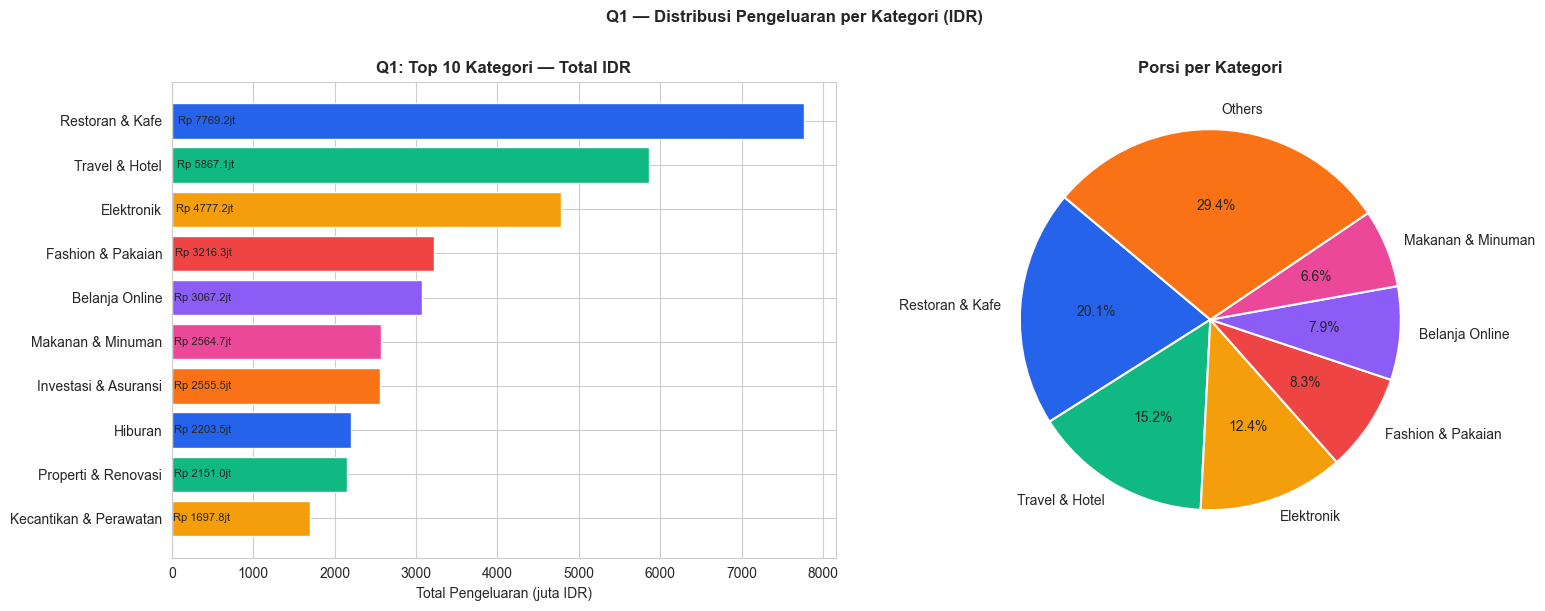


📌 Q1 ANSWER:
   Tidak ada kategori tunggal ≥ 30%.
   Terbesar: Restoran & Kafe (20.1% · Rp 7769.2jt)
   ➡️  BUDU: tampilkan top-3 sebagai "Money Leak Priority"


In [11]:
# ── Q1: Kategori vs Total Pengeluaran IDR ───────────────────
cat_grp = (df.groupby('category')['amount']
             .agg(total='sum', count='count', avg='mean')
             .sort_values('total', ascending=False))
cat_grp['persen'] = (cat_grp['total'] / cat_grp['total'].sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16,6))

top10 = cat_grp.head(10)
clrs  = [PALETTE[i % len(PALETTE)] for i in range(len(top10))]
axes[0].barh(top10.index[::-1], top10['total'][::-1]/1e6, color=clrs[::-1])
axes[0].set_xlabel('Total Pengeluaran (juta IDR)')
axes[0].set_title('Q1: Top 10 Kategori — Total IDR', fontweight='bold')
for i, v in enumerate(top10['total'][::-1]/1e6):
    axes[0].text(v*0.01, i, f'Rp {v:.1f}jt', va='center', fontsize=8)

top6  = cat_grp.head(6)
other = cat_grp['total'].iloc[6:].sum()
pie_v = list(top6['total']) + ([other] if other>0 else [])
pie_l = list(top6.index)    + (['Others'] if other>0 else [])
axes[1].pie(pie_v, labels=pie_l, autopct='%1.1f%%',
            colors=PALETTE[:len(pie_v)], startangle=140,
            wedgeprops=dict(edgecolor='white', lw=1.5))
axes[1].set_title('Porsi per Kategori', fontweight='bold')

plt.suptitle('Q1 — Distribusi Pengeluaran per Kategori (IDR)', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

cat_30 = cat_grp[cat_grp['persen'] >= 30]
print('\n📌 Q1 ANSWER:')
if cat_30.empty:
    top1 = cat_grp.head(1)
    print(f'   Tidak ada kategori tunggal ≥ 30%.')
    print(f'   Terbesar: {top1.index[0]} ({top1["persen"].values[0]:.1f}% · Rp {top1["total"].values[0]/1e6:.1f}jt)')
    print('   ➡️  BUDU: tampilkan top-3 sebagai "Money Leak Priority"')
else:
    for cat, row in cat_30.iterrows():
        print(f'   ⚠️  {cat}: {row["persen"]:.1f}% — Rp {row["total"]/1e6:.1f}jt')
    print('   ➡️  BUDU: aktifkan Money Leak alert untuk kategori ini')


### Cell 14 — Q2: Pola Waktu Pengeluaran

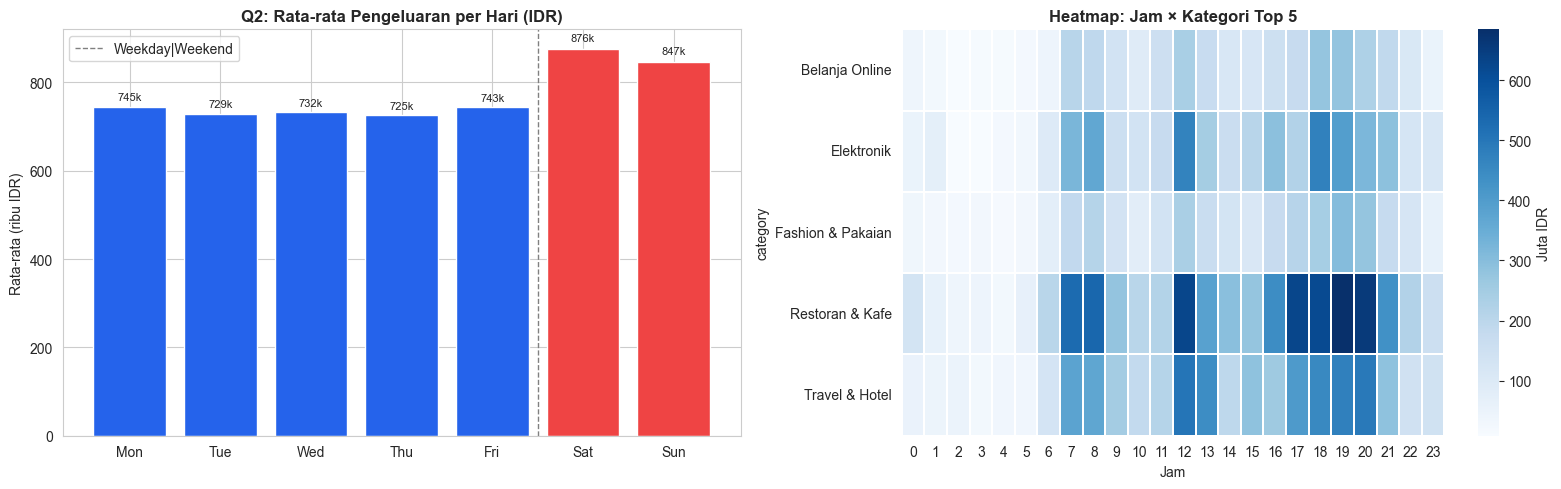


📌 Q2 PREVIEW (diuji di Cell 7 A/B Test):
   Weekend avg: Rp 861,443  |  Weekday avg: Rp 734,825  |  Selisih: +17.2%


In [12]:
# ── Q2: Pola Waktu Pengeluaran ──────────────────────────────
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_avg   = df.groupby('day_name')['amount'].mean().reindex(day_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16,5))
bar_c = ['#EF4444' if d in ['Sat','Sun'] else PRIMARY for d in day_order]
axes[0].bar(day_order, day_avg/1e3, color=bar_c)
axes[0].set_ylabel('Rata-rata (ribu IDR)')
axes[0].set_title('Q2: Rata-rata Pengeluaran per Hari (IDR)', fontweight='bold')
axes[0].axvline(4.5, color='gray', ls='--', lw=1, label='Weekday|Weekend')
axes[0].legend()
for i, v in enumerate(day_avg/1e3):
    axes[0].text(i, v+v*0.02, f'{v:.0f}k', ha='center', fontsize=8)

# Heatmap jam × top-5 kategori
top5 = df.groupby('category')['amount'].sum().nlargest(5).index
hm   = (df[df['category'].isin(top5)]
        .groupby(['hour','category'])['amount'].sum().unstack(fill_value=0))
sns.heatmap(hm.T/1e6, cmap='Blues', ax=axes[1],
            linewidths=0.3, cbar_kws={'label':'Juta IDR'})
axes[1].set_title('Heatmap: Jam × Kategori Top 5', fontweight='bold')
axes[1].set_xlabel('Jam')
plt.tight_layout(); plt.show()

wknd = day_avg[['Sat','Sun']].mean()
wkdy = day_avg[['Mon','Tue','Wed','Thu','Fri']].mean()
diff = (wknd-wkdy)/wkdy*100
print(f'\n📌 Q2 PREVIEW (diuji di Cell 7 A/B Test):')
print(f'   Weekend avg: Rp {wknd:,.0f}  |  Weekday avg: Rp {wkdy:,.0f}  |  Selisih: {diff:+.1f}%')


### Cell 15 — Q3: Anomali Bulanan

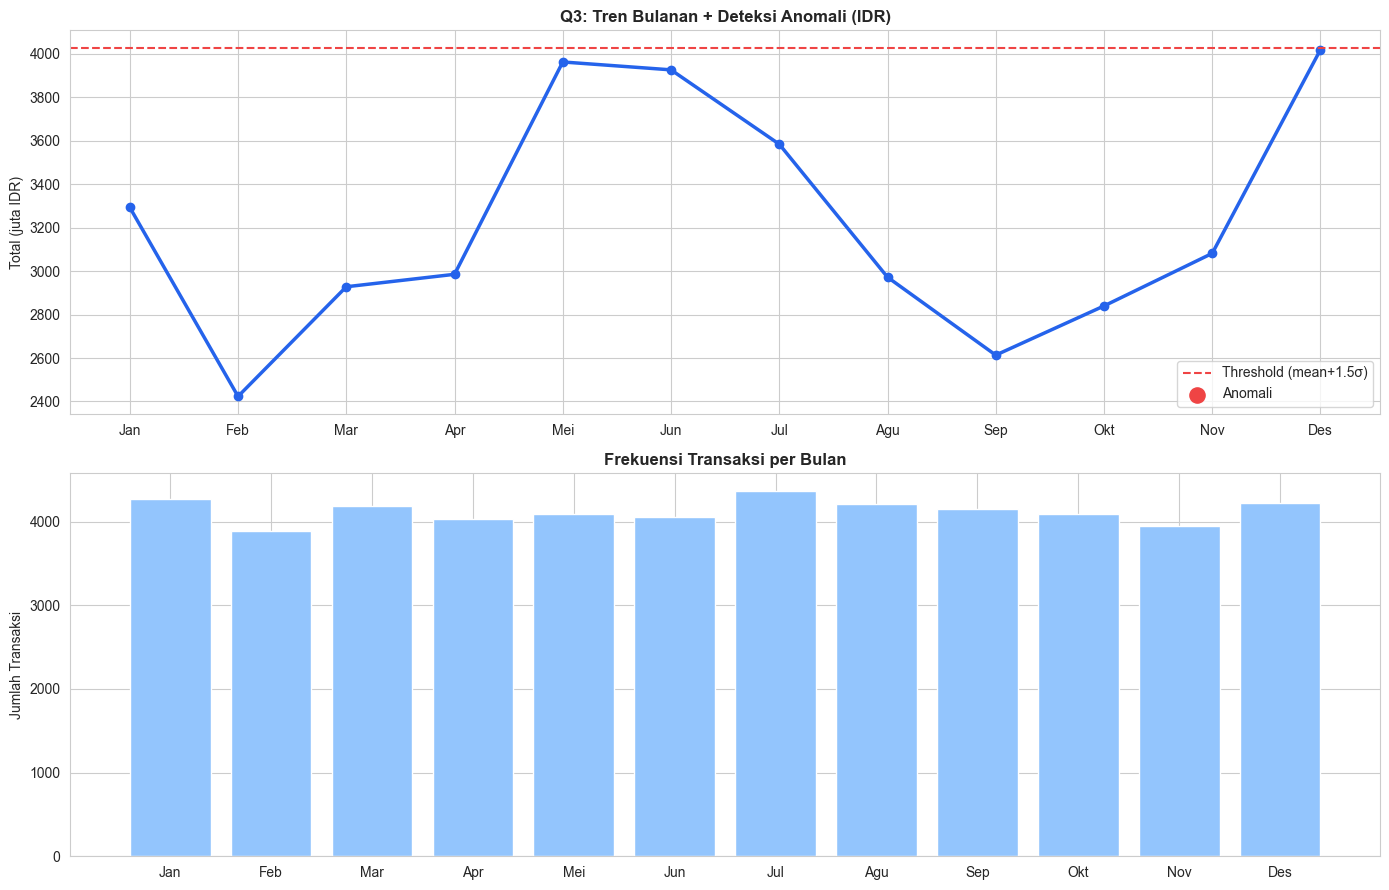


📌 Q3 ANSWER:
   Bulan anomali    : Tidak ada
   Threshold IDR    : Rp 4027.7 juta/bulan
   ➡️  BUDU: tandai di Weekly Reflection sebagai periode risiko tinggi


In [13]:
# ── Q3: Anomali Bulanan ─────────────────────────────────────
monthly = (df.groupby('month')['amount']
             .agg(total='sum', count='count', avg='mean')
             .reset_index())
thr              = monthly['total'].mean() + ANOMALY_STD_FACTOR * monthly['total'].std()
monthly['anomaly'] = monthly['total'] > thr
m_lbl            = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

fig, axes = plt.subplots(2, 1, figsize=(14,9))
axes[0].plot(monthly['month'], monthly['total']/1e6, marker='o', color=PRIMARY, lw=2.5)
axes[0].axhline(thr/1e6, color=WARN, ls='--', lw=1.5, label=f'Threshold (mean+{ANOMALY_STD_FACTOR}σ)')
anom = monthly[monthly['anomaly']]
axes[0].scatter(anom['month'], anom['total']/1e6, color=WARN, s=120, zorder=5, label='Anomali')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(m_lbl)
axes[0].set_ylabel('Total (juta IDR)'); axes[0].legend()
axes[0].set_title('Q3: Tren Bulanan + Deteksi Anomali (IDR)', fontweight='bold')
axes[1].bar(monthly['month'], monthly['count'],
            color=['#EF4444' if a else '#93C5FD' for a in monthly['anomaly']])
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(m_lbl)
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].set_title('Frekuensi Transaksi per Bulan', fontweight='bold')
plt.tight_layout(); plt.show()

anom_names = [m_lbl[m-1] for m in anom['month'].tolist()]
print(f'\n📌 Q3 ANSWER:')
print(f'   Bulan anomali    : {anom_names if anom_names else "Tidak ada"}')
print(f'   Threshold IDR    : Rp {thr/1e6:.1f} juta/bulan')
print('   ➡️  BUDU: tandai di Weekly Reflection sebagai periode risiko tinggi')


### Cell 16 — Q4: Money Leak Detection

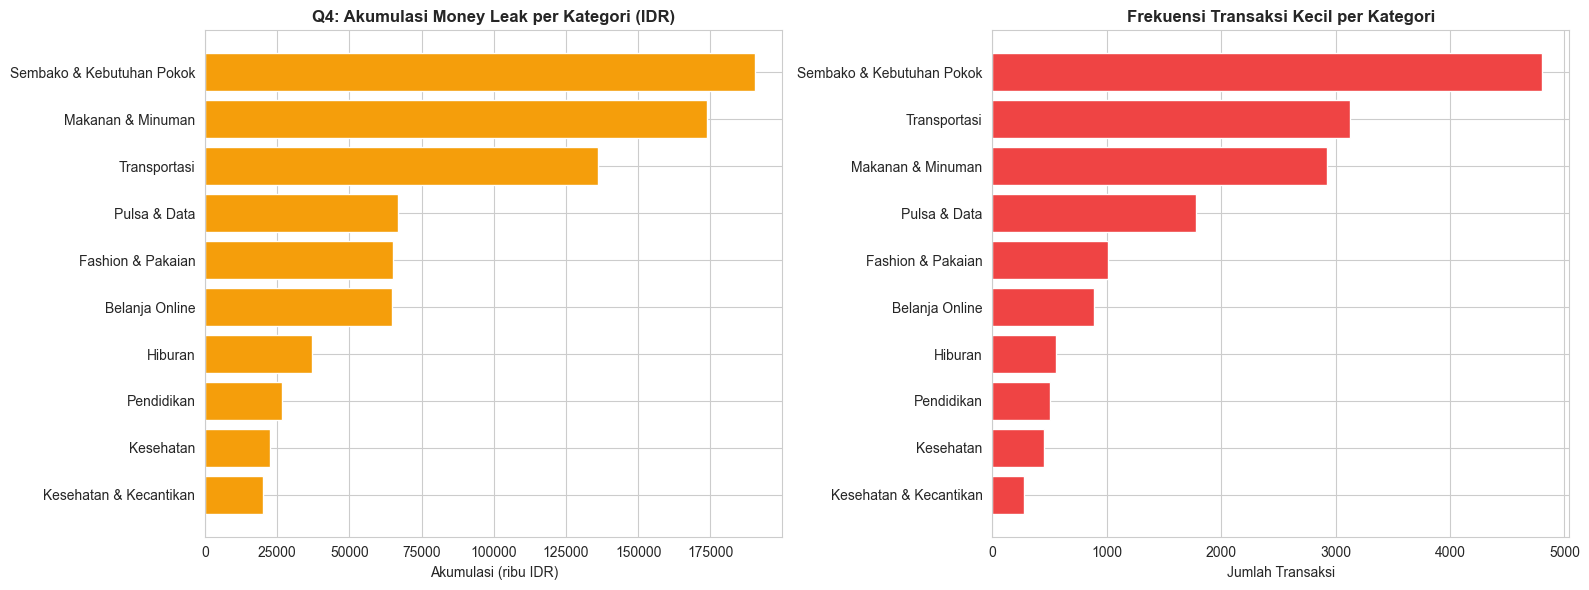


📌 Q4 ANSWER:
   Batas transaksi "kecil" : ≤ Rp 105,200
   Total bocor             : Rp 807.3 juta
   ⚠️  Sembako & Kebutuhan Pokok: 400.2×/bln · akumulasi Rp 190,375k
   ⚠️  Makanan & Minuman: 243.9×/bln · akumulasi Rp 173,779k
   ⚠️  Transportasi: 260.2×/bln · akumulasi Rp 136,014k
   ⚠️  Pulsa & Data: 148.1×/bln · akumulasi Rp 66,754k
   ⚠️  Fashion & Pakaian: 84.5×/bln · akumulasi Rp 65,229k
   ➡️  BUDU: tampilkan kartu "Silent Money Leak" untuk kategori ini


In [14]:
# ── Q4: Money Leak Detection ────────────────────────────────
median_idr  = df['amount'].median()
small_lim   = median_idr * SMALL_TXN_MULTIPLIER
df_small    = df[df['amount'] <= small_lim]
n_months    = max(df['month'].nunique(), 1)

leak = (df_small.groupby('category')
        .agg(total_idr=('amount','sum'), freq=('amount','count'),
             avg_idr=('amount','mean'))
        .assign(freq_monthly=lambda x: x['freq']/n_months)
        .query(f'freq_monthly >= {FREQ_MONTH_THRESH}')
        .sort_values('total_idr', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16,6))
if not leak.empty:
    lt = leak.sort_values('total_idr')
    axes[0].barh(lt.index, lt['total_idr']/1e3, color='#F59E0B')
    axes[1].barh(leak.sort_values('freq').index,
                 leak.sort_values('freq')['freq'], color=WARN)
else:
    # Fallback: tampilkan top 10 tanpa threshold
    leak_all = (df_small.groupby('category')
                .agg(total_idr=('amount','sum'), freq=('amount','count'))
                .sort_values('total_idr', ascending=False).head(10))
    axes[0].barh(leak_all.index[::-1], leak_all['total_idr'][::-1]/1e3, color='#F59E0B')
    axes[1].barh(leak_all.index[::-1], leak_all['freq'][::-1], color=WARN)

axes[0].set_title('Q4: Akumulasi Money Leak per Kategori (IDR)', fontweight='bold')
axes[0].set_xlabel('Akumulasi (ribu IDR)')
axes[1].set_title('Frekuensi Transaksi Kecil per Kategori', fontweight='bold')
axes[1].set_xlabel('Jumlah Transaksi')
plt.tight_layout(); plt.show()

print(f'\n📌 Q4 ANSWER:')
print(f'   Batas transaksi "kecil" : ≤ Rp {small_lim:,.0f}')
print(f'   Total bocor             : Rp {df_small["amount"].sum()/1e6:,.1f} juta')
if not leak.empty:
    for cat, row in leak.head(5).iterrows():
        print(f'   ⚠️  {cat}: {row["freq_monthly"]:.1f}×/bln · akumulasi Rp {row["total_idr"]/1e3:,.0f}k')
print('   ➡️  BUDU: tampilkan kartu "Silent Money Leak" untuk kategori ini')


### Cell 17 — Q5: Metode Pembayaran + Spearman

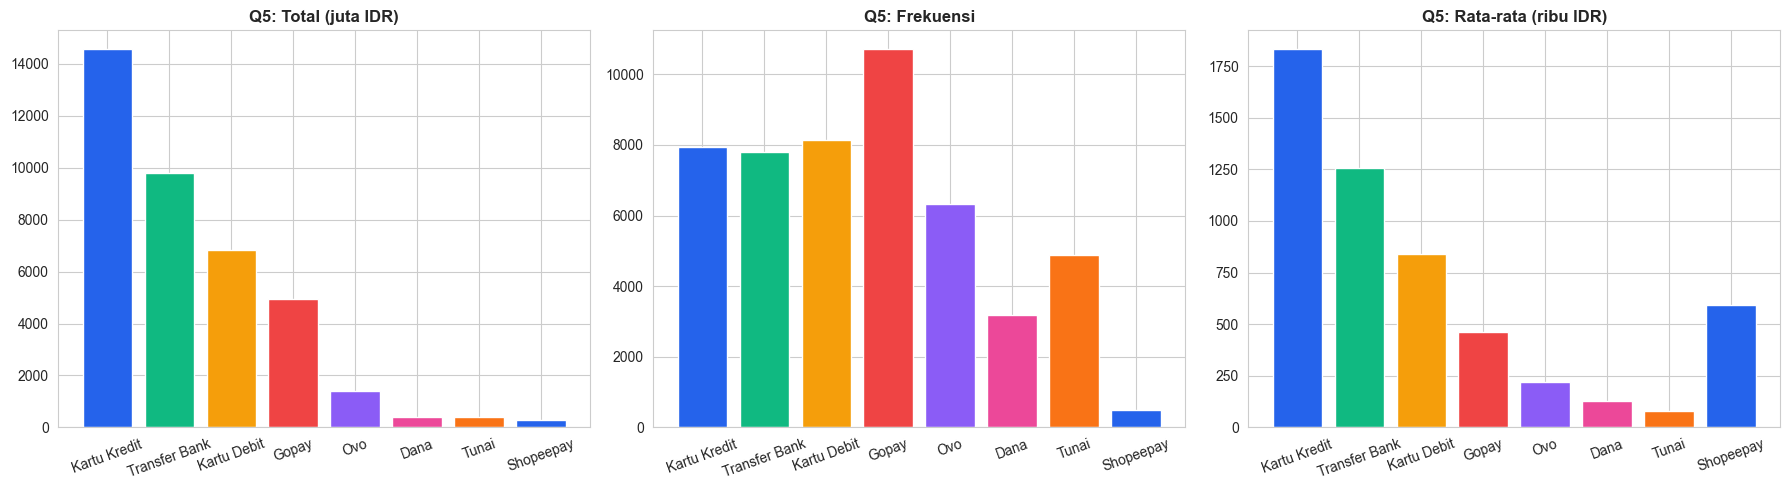


📌 Q5 ANSWER:
   Spearman ρ: 0.0054  |  p-value: 0.2290
   ℹ️  Korelasi lemah (ρ=0.01 < 0.3) — metode bayar bukan prediktor kuat nilai


,total,count,avg
payment_method,,,
Kartu Kredit,14557717900,7950,"1,831,159.48"
Transfer Bank,9782360400,7785,"1,256,565.24"
Kartu Debit,6832289800,8150,"838,317.77"
Gopay,4958895500,10706,"463,188.45"
Ovo,1401066600,6334,"221,197.76"
Dana,407728400,3186,"127,975.02"
Tunai,393607700,4889,"80,508.84"
Shopeepay,296465100,501,"591,746.71"


In [15]:
# ── Q5: Metode Pembayaran + Spearman ────────────────────────
pay = (df.groupby('payment_method')['amount']
         .agg(total='sum', count='count', avg='mean')
         .sort_values('total', ascending=False))

pay_enc = df['payment_method'].astype('category').cat.codes
rho, pval = spearmanr(pay_enc, df['amount'])

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for i, (col, lbl, div) in enumerate([
        ('total','Total (juta IDR)',1e6),
        ('count','Frekuensi',1),
        ('avg','Rata-rata (ribu IDR)',1e3)]):
    axes[i].bar(pay.index, pay[col]/div, color=PALETTE[:len(pay)])
    axes[i].set_title(f'Q5: {lbl}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

print(f'\n📌 Q5 ANSWER:')
print(f'   Spearman ρ: {rho:.4f}  |  p-value: {pval:.4f}')
if abs(rho) >= 0.3:
    print(f'   ✅ Korelasi signifikan (ρ={rho:.2f} ≥ 0.3)')
    print('   ➡️  BUDU: sesuaikan konteks peringatan berdasarkan metode bayar')
else:
    print(f'   ℹ️  Korelasi lemah (ρ={rho:.2f} < 0.3) — metode bayar bukan prediktor kuat nilai')
display(pay.head(10))


### Cell 18 — EDA Tambahan: Distribusi per Segmen Ekonomi Indonesia

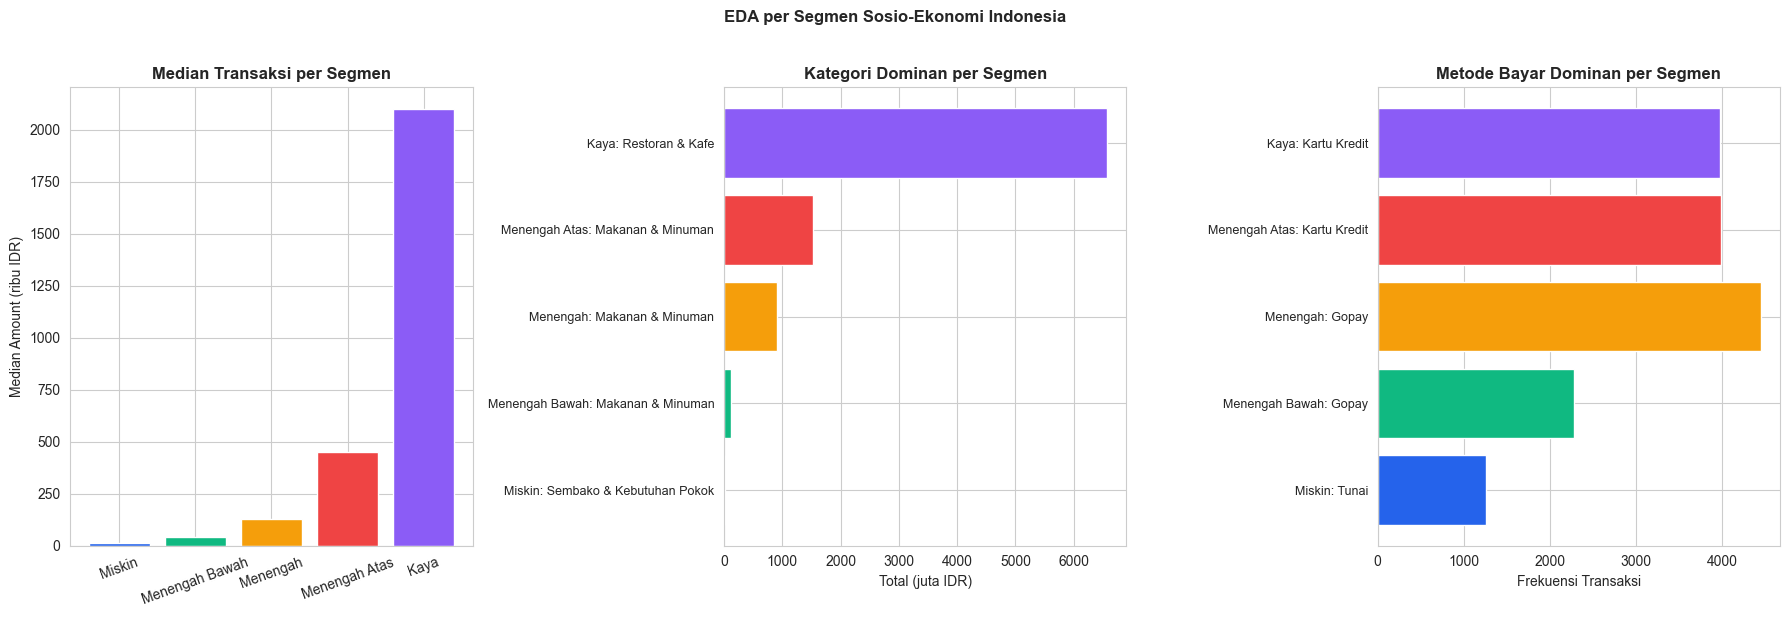


Median amount per segmen (IDR):
  Kelas E (Miskin)                   : Rp     15,100  (2,315 txn)
  Kelas D (Menengah Bawah)           : Rp     41,600  (7,597 txn)
  Kelas C (Menengah)                 : Rp    128,700  (17,378 txn)
  Kelas B (Menengah Atas)            : Rp    449,400  (13,372 txn)
  Kelas A (Kaya)                     : Rp  2,098,600  (8,839 txn)


In [16]:
# ============================================================
# CELL 18 — EDA per Segmen Ekonomi (khusus data dummy)
# ============================================================
if DATA_MODE == 'dummy' and 'segmen_label' in df.columns:
    seg_order = ['Kelas E (Miskin)','Kelas D (Menengah Bawah)',
                 'Kelas C (Menengah)','Kelas B (Menengah Atas)','Kelas A (Kaya)']
    seg_avail = [s for s in seg_order if s in df['segmen_label'].unique()]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Median amount per segmen
    seg_med = df.groupby('segmen_label')['amount'].median().reindex(seg_avail)
    axes[0].bar(range(len(seg_med)), seg_med.values/1e3,
                color=PALETTE[:len(seg_med)])
    axes[0].set_xticks(range(len(seg_med)))
    axes[0].set_xticklabels([s.split('(')[1].rstrip(')') for s in seg_avail], rotation=20)
    axes[0].set_ylabel('Median Amount (ribu IDR)')
    axes[0].set_title('Median Transaksi per Segmen', fontweight='bold')

    # 2. Kategori dominan per segmen (top 1)
    top_cat = df.groupby(['segmen_label','category'])['amount'].sum()
    top_cat = top_cat.reset_index().sort_values('amount', ascending=False)
    top_cat = top_cat.groupby('segmen_label').first().reindex(seg_avail)
    axes[1].barh(range(len(top_cat)), top_cat['amount'].values/1e6,
                 color=PALETTE[:len(top_cat)])
    axes[1].set_yticks(range(len(top_cat)))
    axes[1].set_yticklabels([f'{s.split("(")[1].rstrip(")")}: {c}'
                              for s, c in zip(top_cat.index, top_cat['category'])],
                             fontsize=9)
    axes[1].set_xlabel('Total (juta IDR)')
    axes[1].set_title('Kategori Dominan per Segmen', fontweight='bold')

    # 3. Metode pembayaran per segmen
    pay_seg = df.groupby(['segmen_label','payment_method'])['amount'].count().reset_index()
    pay_seg = pay_seg.sort_values('amount', ascending=False)
    top_pay = pay_seg.groupby('segmen_label').first().reindex(seg_avail)
    axes[2].barh(range(len(top_pay)), top_pay['amount'].values,
                 color=PALETTE[:len(top_pay)])
    axes[2].set_yticks(range(len(top_pay)))
    axes[2].set_yticklabels([f'{s.split("(")[1].rstrip(")")}: {p}'
                              for s, p in zip(top_pay.index, top_pay['payment_method'])],
                             fontsize=9)
    axes[2].set_xlabel('Frekuensi Transaksi')
    axes[2].set_title('Metode Bayar Dominan per Segmen', fontweight='bold')

    plt.suptitle('EDA per Segmen Sosio-Ekonomi Indonesia', fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

    print('\nMedian amount per segmen (IDR):')
    for seg in seg_avail:
        med = df[df['segmen_label']==seg]['amount'].median()
        cnt = len(df[df['segmen_label']==seg])
        print(f'  {seg:35s}: Rp {med:>10,.0f}  ({cnt:,} txn)')
else:
    print('Segmen ekonomi tidak tersedia (mode Kaggle). Skip visualisasi ini.')


---
## 🧪 BAGIAN I — A/B Testing

### Cell 19 — Mann-Whitney U: Weekend vs Weekday

🧪 A/B TEST — Weekend vs Weekday · BUDU · IDR
  H0: Tidak ada perbedaan rata-rata pengeluaran
  H1: Pengeluaran weekend ≥ 20% lebih tinggi

  Grup A (Weekend)  n=17,811
    Mean   : Rp       861,410
    Median : Rp       237,000
    Std    : Rp     1,784,097

  Grup B (Weekday)  n=31,690
    Mean   : Rp       734,855
    Median : Rp       197,100
    Std    : Rp     1,590,405

  Selisih mean   : +17.2%  (threshold Q2: ≥ +20%)
  Mann-Whitney U : 301,200,594
  p-value        : 0.000000
  Effect size r  : inf  (kecil<0.1 | sedang 0.1–0.3 | besar>0.3)

  ⚠️  Signifikan statistik, tapi selisih 17.2% < 20%
  📌 BUDU: tampilkan insight weekend, belum trigger warning otomatis


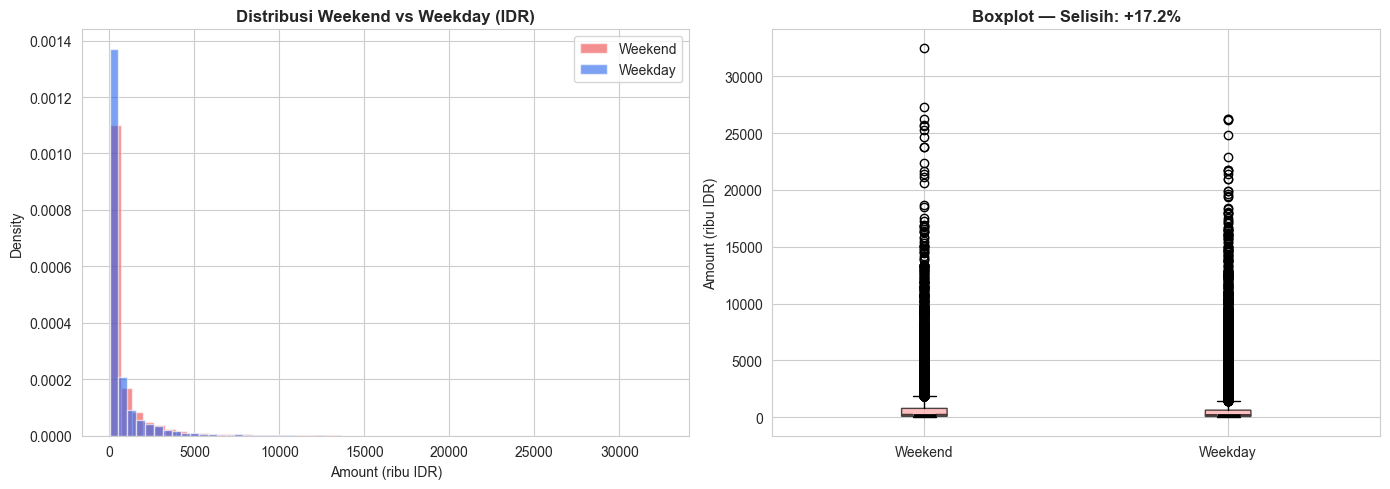

In [17]:
# ============================================================
# CELL 7 — A/B Testing · Q2 BUDU · Mann-Whitney U
# H0: Tidak ada perbedaan rata-rata pengeluaran weekend vs weekday
# H1: Pengeluaran weekend ≥ 20% lebih tinggi dari weekday
# Uji: Mann-Whitney U (non-parametrik)  |  α = 0.05
# ============================================================
grp_w = df[df['is_weekend']==1]['amount']
grp_d = df[df['is_weekend']==0]['amount']

u_stat, p_val = mannwhitneyu(grp_w, grp_d, alternative='greater')
n_total  = len(grp_w) + len(grp_d)
z_score  = stats.norm.ppf(1 - p_val)
effect_r = z_score / np.sqrt(n_total)
pct_diff = (grp_w.mean() - grp_d.mean()) / grp_d.mean() * 100

alpha = 0.05; thr_pct = 20

print('='*65)
print('🧪 A/B TEST — Weekend vs Weekday · BUDU · IDR')
print('='*65)
print(f'  H0: Tidak ada perbedaan rata-rata pengeluaran')
print(f'  H1: Pengeluaran weekend ≥ {thr_pct}% lebih tinggi')
print()
print(f'  Grup A (Weekend)  n={len(grp_w):,}')
print(f'    Mean   : Rp {grp_w.mean():>13,.0f}')
print(f'    Median : Rp {grp_w.median():>13,.0f}')
print(f'    Std    : Rp {grp_w.std():>13,.0f}')
print()
print(f'  Grup B (Weekday)  n={len(grp_d):,}')
print(f'    Mean   : Rp {grp_d.mean():>13,.0f}')
print(f'    Median : Rp {grp_d.median():>13,.0f}')
print(f'    Std    : Rp {grp_d.std():>13,.0f}')
print()
print(f'  Selisih mean   : {pct_diff:+.1f}%  (threshold Q2: ≥ +{thr_pct}%)')
print(f'  Mann-Whitney U : {u_stat:,.0f}')
print(f'  p-value        : {p_val:.6f}')
print(f'  Effect size r  : {effect_r:.4f}  (kecil<0.1 | sedang 0.1–0.3 | besar>0.3)')
print()

if p_val < alpha and pct_diff >= thr_pct:
    print(f'  ✅ TOLAK H0 — signifikan DAN selisih ≥ {thr_pct}%')
    print('  📌 BUDU: aktifkan Smart Warning otomatis setiap Jumat malam')
elif p_val < alpha:
    print(f'  ⚠️  Signifikan statistik, tapi selisih {pct_diff:.1f}% < {thr_pct}%')
    print('  📌 BUDU: tampilkan insight weekend, belum trigger warning otomatis')
else:
    print(f'  ℹ️  Gagal tolak H0 (p={p_val:.4f} ≥ {alpha})')

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for g, lbl, clr in [(grp_w,'Weekend',WARN),(grp_d,'Weekday',PRIMARY)]:
    axes[0].hist(g/1e3, bins=50, alpha=0.6, label=lbl, color=clr, density=True)
axes[0].set_xlabel('Amount (ribu IDR)'); axes[0].set_ylabel('Density')
axes[0].set_title('Distribusi Weekend vs Weekday (IDR)', fontweight='bold')
axes[0].legend()
bp = axes[1].boxplot([grp_w/1e3, grp_d/1e3], labels=['Weekend','Weekday'],
                     patch_artist=True, notch=True,
                     boxprops=dict(facecolor='#FCA5A5', alpha=0.7),
                     medianprops=dict(color='black', lw=2))
axes[1].set_ylabel('Amount (ribu IDR)')
axes[1].set_title(f'Boxplot — Selisih: {pct_diff:+.1f}%', fontweight='bold')
plt.tight_layout(); plt.show()


---
## 🔧 BAGIAN J — Feature Engineering

### Cell 20 — Feature Engineering Level Transaksi

In [18]:
# ============================================================
# CELL 8a — Feature Engineering Level Transaksi
# ============================================================

# ── Bucket IDR (konteks lokal Indonesia) ────────────────────
bins_idr   = [0, 50_000, 200_000, 500_000, 1_000_000, float('inf')]
lbl_idr    = ['<50k','50k-200k','200k-500k','500k-1jt','>1jt']
df['amount_idr_bucket'] = pd.cut(df['amount'], bins=bins_idr, labels=lbl_idr)

# ── Di atas rata-rata global ─────────────────────────────────
df['above_avg'] = (df['amount'] > df['amount'].mean()).astype(int)

# ── Frequency encoding kategori ─────────────────────────────
cat_freq = df['category'].value_counts(normalize=True).to_dict()
df['category_freq_enc'] = df['category'].map(cat_freq)

# ── Fitur jarak (sudah dihitung di Cell 4) ──────────────────
if 'dist_user_merchant' not in df.columns:
    df['dist_user_merchant'] = 0.0

# ── Usia saat transaksi (kategori) ──────────────────────────
df['age_group'] = pd.cut(df['age'].fillna(25),
                          bins=[0,17,24,34,44,99],
                          labels=['<18','18-24','25-34','35-44','45+'])

# ── Lag & rolling per user ───────────────────────────────────
df_s = df.sort_values(['user_id','date']).copy()
df_s['amount_lag1']   = df_s.groupby('user_id')['amount'].shift(1)
df_s['amount_diff']   = (df_s['amount'] - df_s['amount_lag1']).fillna(0)
df_s['rolling_7txn']  = (df_s.groupby('user_id')['amount']
                          .transform(lambda x: x.rolling(7, min_periods=1).sum()))
df_s['rolling_30txn'] = (df_s.groupby('user_id')['amount']
                          .transform(lambda x: x.rolling(30, min_periods=1).sum()))
# Deteksi spike: amount > 2× rolling mean 7 transaksi terakhir
df_s['rolling_7_mean'] = (df_s.groupby('user_id')['amount']
                           .transform(lambda x: x.rolling(7, min_periods=1).mean()))
df_s['is_spike'] = (df_s['amount'] > df_s['rolling_7_mean'] * 2).astype(int)
df = df_s.reset_index(drop=True)

print('✅ Feature Engineering Level Transaksi:')
feats_txn = ['amount_idr_bucket','above_avg','category_freq_enc',
             'dist_user_merchant','age_group','amount_lag1',
             'amount_diff','rolling_7txn','rolling_30txn','is_spike']
for f in feats_txn:
    print(f'   {f:30s} → {df[f].dtype}')


✅ Feature Engineering Level Transaksi:
   amount_idr_bucket              → category
   above_avg                      → int32
   category_freq_enc              → float64
   dist_user_merchant             → float64
   age_group                      → category
   amount_lag1                    → float64
   amount_diff                    → float64
   rolling_7txn                   → float64
   rolling_30txn                  → float64
   is_spike                       → int32


### Cell 21 — Feature Engineering Level User

✅ User Profiles: 1000 user × 40 fitur

   Range impulse_score: 0.030 – 0.478
   Avg total spending : Rp 38,630,131


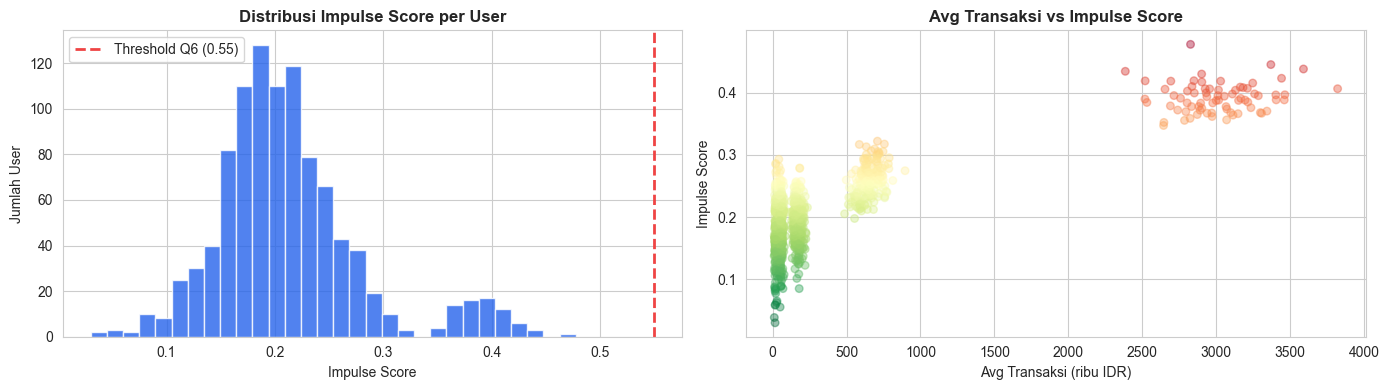

In [19]:
# ============================================================
# CELL 8b — Feature Engineering Level USER
# ============================================================
user_agg = df.groupby('user_id').agg(
    # Spending volume
    total_spending_idr    = ('amount', 'sum'),
    avg_txn_idr           = ('amount', 'mean'),
    median_txn_idr        = ('amount', 'median'),
    max_txn_idr           = ('amount', 'max'),
    txn_count             = ('amount', 'count'),
    std_amount_idr        = ('amount', 'std'),
    # Temporal behavior
    weekend_ratio         = ('is_weekend', 'mean'),
    night_ratio           = ('is_night', 'mean'),
    month_start_ratio     = ('is_month_start', 'mean'),
    month_end_ratio       = ('is_month_end', 'mean'),
    above_avg_ratio       = ('above_avg', 'mean'),
    spike_ratio           = ('is_spike', 'mean'),
    # Diversity
    unique_categories     = ('category', 'nunique'),
    unique_merchants      = ('sub_category', 'nunique'),
    active_months         = ('month', 'nunique'),
    # Fraud signal
    fraud_ratio           = ('is_fraud', 'mean') if 'is_fraud' in df.columns else ('amount', 'count'),
    # Geography
    avg_dist_merchant     = ('dist_user_merchant', 'mean'),
).reset_index()

user_agg['std_amount_idr'].fillna(0, inplace=True)

# Koefisien variasi (volatilitas belanja)
user_agg['spending_cov'] = (
    user_agg['std_amount_idr'] /
    user_agg['avg_txn_idr'].replace(0, np.nan)).fillna(0)

# Impulse score gabungan
user_agg['impulse_score'] = (
    user_agg['weekend_ratio']   * 0.35 +
    user_agg['night_ratio']     * 0.30 +
    user_agg['above_avg_ratio'] * 0.20 +
    user_agg['spike_ratio']     * 0.15).round(4)

# Pivot kategori per user (spending profile)
cat_pivot = (df.pivot_table(index='user_id', columns='category',
                             values='amount', aggfunc='sum', fill_value=0))
cat_pivot.columns = [
    f'cat_{str(c).lower().replace(" ","_")[:15]}' for c in cat_pivot.columns]

# Metode pembayaran dominan
pay_dom = (df.groupby('user_id')['payment_method']
             .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown')
             .reset_index().rename(columns={'payment_method':'dominant_payment'}))

# Gender & job dominan per user (kalau ada)
extra_cols = {}
if 'gender' in df.columns:
    extra_cols['gender'] = df.groupby('user_id')['gender'].agg(
        lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown').reset_index()
if 'age' in df.columns:
    extra_cols['age'] = df.groupby('user_id')['age'].mean().reset_index()

user_features = (user_agg
                 .merge(cat_pivot, on='user_id', how='left')
                 .merge(pay_dom,   on='user_id', how='left'))
for k, v in extra_cols.items():
    user_features = user_features.merge(v, on='user_id', how='left')

user_features.fillna(0, inplace=True)

print(f'✅ User Profiles: {user_features.shape[0]} user × {user_features.shape[1]} fitur')
print(f'\n   Range impulse_score: {user_features["impulse_score"].min():.3f} – {user_features["impulse_score"].max():.3f}')
print(f'   Avg total spending : Rp {user_features["total_spending_idr"].mean():,.0f}')

# Visualisasi distribusi impulse_score
fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].hist(user_features['impulse_score'], bins=30, color=PRIMARY, alpha=0.8, edgecolor='white')
axes[0].axvline(IMPULSE_THRESHOLD, color=WARN, ls='--', lw=2, label=f'Threshold Q6 ({IMPULSE_THRESHOLD})')
axes[0].set_xlabel('Impulse Score'); axes[0].set_ylabel('Jumlah User')
axes[0].set_title('Distribusi Impulse Score per User', fontweight='bold')
axes[0].legend()
axes[1].scatter(user_features['avg_txn_idr']/1e3,
                user_features['impulse_score'],
                alpha=0.4, c=user_features['impulse_score'],
                cmap='RdYlGn_r', s=30)
axes[1].set_xlabel('Avg Transaksi (ribu IDR)'); axes[1].set_ylabel('Impulse Score')
axes[1].set_title('Avg Transaksi vs Impulse Score', fontweight='bold')
plt.tight_layout(); plt.show()


---
## 🤖 BAGIAN K — Spending Personality Clustering

### Cell 22 — Elbow + Silhouette

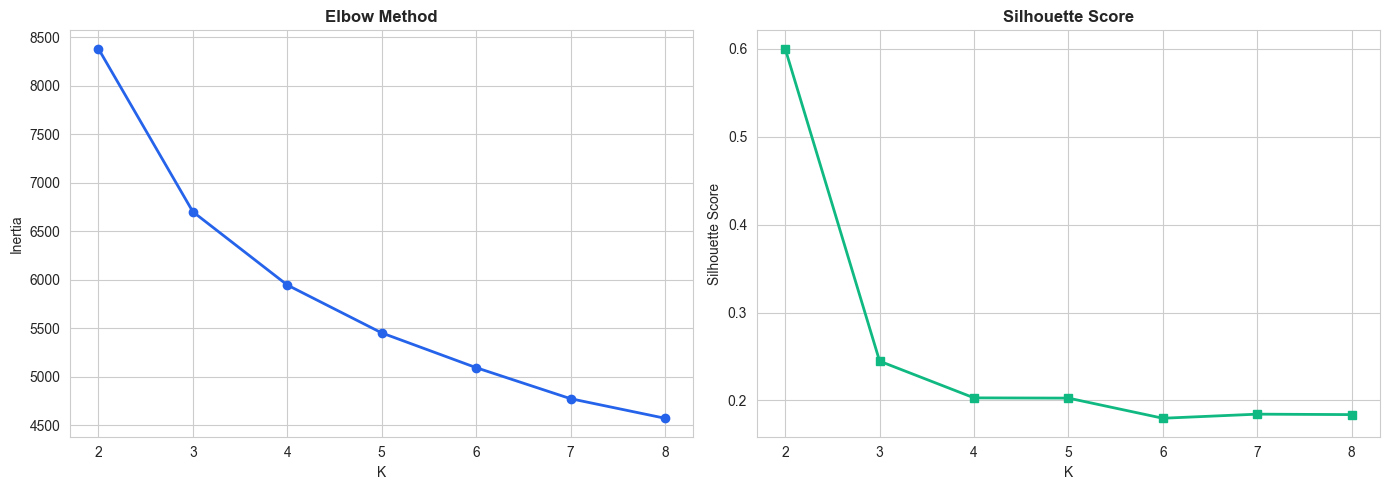

✅ K terbaik: 2  (Silhouette: 0.5998)


In [20]:
# ============================================================
# CELL 9a — Pilih K optimal
# ============================================================
FEATURE_COLS = [
    'total_spending_idr','avg_txn_idr','median_txn_idr',
    'txn_count','std_amount_idr','weekend_ratio','night_ratio',
    'unique_categories','impulse_score','spending_cov',
    'above_avg_ratio','spike_ratio','active_months','avg_dist_merchant'
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in user_features.columns]

X = user_features[FEATURE_COLS].fillna(0).values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(K_range, inertias,  marker='o', color=PRIMARY, lw=2)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[1].plot(K_range, sil_scores, marker='s', color=ACCENT, lw=2)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')
plt.tight_layout(); plt.show()

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f'✅ K terbaik: {best_k}  (Silhouette: {max(sil_scores):.4f})')


### Cell 23 — Final Clustering + Label Persona

Statistik cluster:
         avg_impulse      avg_spend      avg_txn  count
cluster                                                
0               0.17   1,487,607.87    52,664.27    356
1               0.39 363,168,875.34 3,008,880.84     73
2               0.22  20,296,348.69   303,991.33    571

📌 Q6 ANSWER — Impulsive Spender (impulse_score ≥ 0.55):
   0/1000 pengguna = 0.0%
   ➡️  BUDU: segmen ini = prioritas utama Smart Warning notification

   Emotional Spender        :  571 user (57.1%)  avg Rp 20,296,349
   Rational Spender         :  356 user (35.6%)  avg Rp 1,487,608
   Impulsive Spender        :   73 user (7.3%)  avg Rp 363,168,875


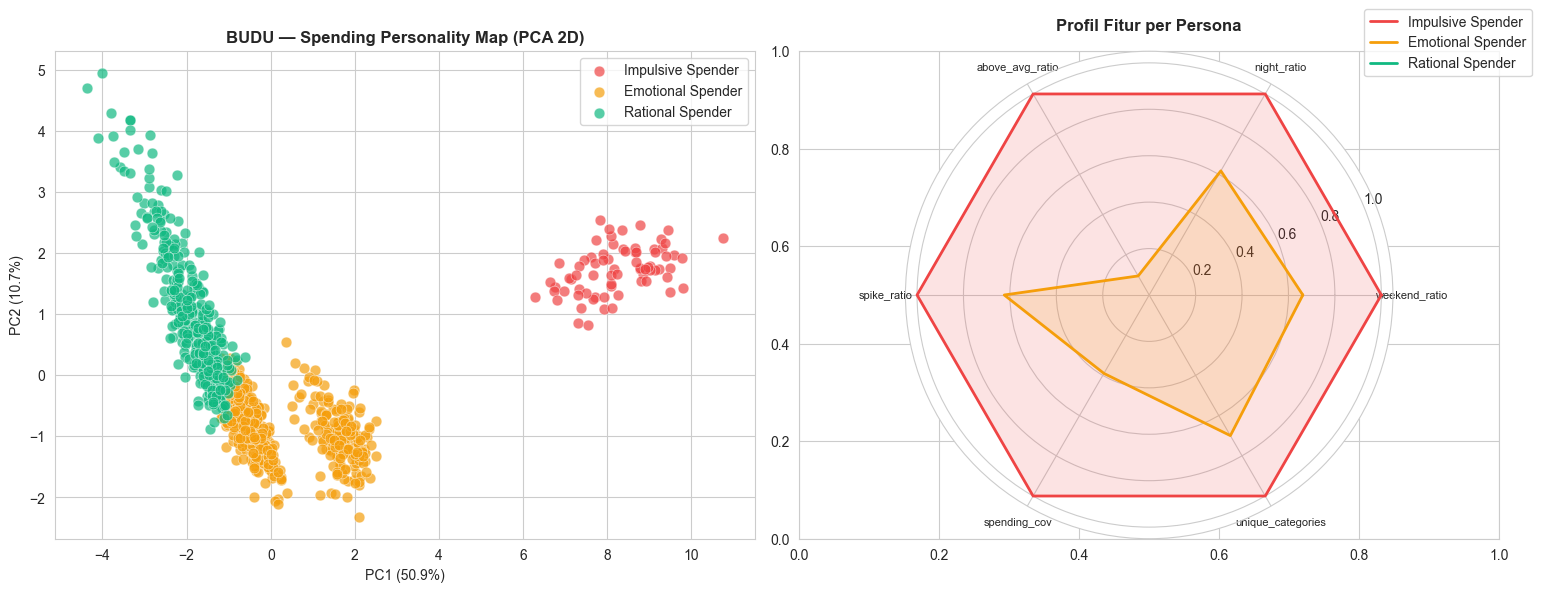

Variance explained PCA: 61.6%


In [21]:
# ============================================================
# CELL 9b — Final Clustering + Label + Q6 Answer
# ============================================================
K_FINAL  = 3   # bisa diubah sesuai elbow/silhouette
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
user_features['cluster'] = km_final.fit_predict(X_scaled)

stats_clust = user_features.groupby('cluster').agg(
    avg_impulse  = ('impulse_score','mean'),
    avg_spend    = ('total_spending_idr','mean'),
    avg_txn      = ('avg_txn_idr','mean'),
    count        = ('user_id','count'),
).round(2)
print('Statistik cluster:'); print(stats_clust)

rank = stats_clust['avg_impulse'].rank(method='first').astype(int)
PERSONA_MAP_K3 = {rank.max():'Impulsive Spender',
                  rank.median():'Emotional Spender',
                  rank.min():'Rational Spender'}
user_features['spending_persona'] = user_features['cluster'].map(
    {c: PERSONA_MAP_K3.get(int(r), f'Persona {r}') for c, r in rank.items()})

# Q6 Answer
n_imp  = (user_features['impulse_score'] >= IMPULSE_THRESHOLD).sum()
n_tot  = len(user_features)
print(f'\n📌 Q6 ANSWER — Impulsive Spender (impulse_score ≥ {IMPULSE_THRESHOLD}):')
print(f'   {n_imp}/{n_tot} pengguna = {n_imp/n_tot*100:.1f}%')
print('   ➡️  BUDU: segmen ini = prioritas utama Smart Warning notification')
print()
for persona, cnt in user_features['spending_persona'].value_counts().items():
    avg_sp = user_features[user_features['spending_persona']==persona]['total_spending_idr'].mean()
    print(f'   {persona:25s}: {cnt:4d} user ({cnt/n_tot*100:.1f}%)  avg Rp {avg_sp:,.0f}')

# PCA 2D
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
cmap  = {'Impulsive Spender':WARN,'Emotional Spender':'#F59E0B','Rational Spender':ACCENT}

fig, axes = plt.subplots(1, 2, figsize=(16,6))
for persona, color in cmap.items():
    mask = user_features['spending_persona'] == persona
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], label=persona,
                    color=color, alpha=0.7, s=60, edgecolors='white', lw=0.4)
axes[0].set_title('BUDU — Spending Personality Map (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Radar chart per persona (spider plot)
radar_feats = ['weekend_ratio','night_ratio','above_avg_ratio',
               'spike_ratio','spending_cov','unique_categories']
radar_feats = [f for f in radar_feats if f in user_features.columns]
persona_means = user_features.groupby('spending_persona')[radar_feats].mean()
persona_means_norm = (persona_means - persona_means.min()) / (persona_means.max() - persona_means.min() + 1e-9)
angles = np.linspace(0, 2*np.pi, len(radar_feats), endpoint=False).tolist()
angles += angles[:1]
ax2 = fig.add_subplot(122, polar=True)
for persona, color in cmap.items():
    if persona in persona_means_norm.index:
        vals = persona_means_norm.loc[persona].tolist() + [persona_means_norm.loc[persona].tolist()[0]]
        ax2.plot(angles, vals, color=color, lw=2, label=persona)
        ax2.fill(angles, vals, color=color, alpha=0.15)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels([f.replace('_ratio','').replace('_',' '), '' , '' , '', '', ''][:len(radar_feats)])
ax2.set_xticklabels(radar_feats, size=8)
ax2.set_title('Profil Fitur per Persona', fontweight='bold', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
plt.tight_layout(); plt.show()
print(f'Variance explained PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%')


---
## 🤖 BAGIAN L — Persiapan Data Model TensorFlow

### Cell 24 — Encode + Normalisasi + Split 70/15/15

Encoding Spending Persona:
  0 → Emotional Spender         (571 user | 57.1%)
  1 → Impulsive Spender         (73 user | 7.3%)
  2 → Rational Spender          (356 user | 35.6%)

📦 Data siap untuk TensorFlow:
   X_train : (700, 14)   y_train: (700,)
   X_val   : (150, 14)   y_val  : (150,)
   X_test  : (150, 14)   y_test : (150,)
   Input features : 14
   Output classes : 3 (['Emotional Spender', 'Impulsive Spender', 'Rational Spender'])


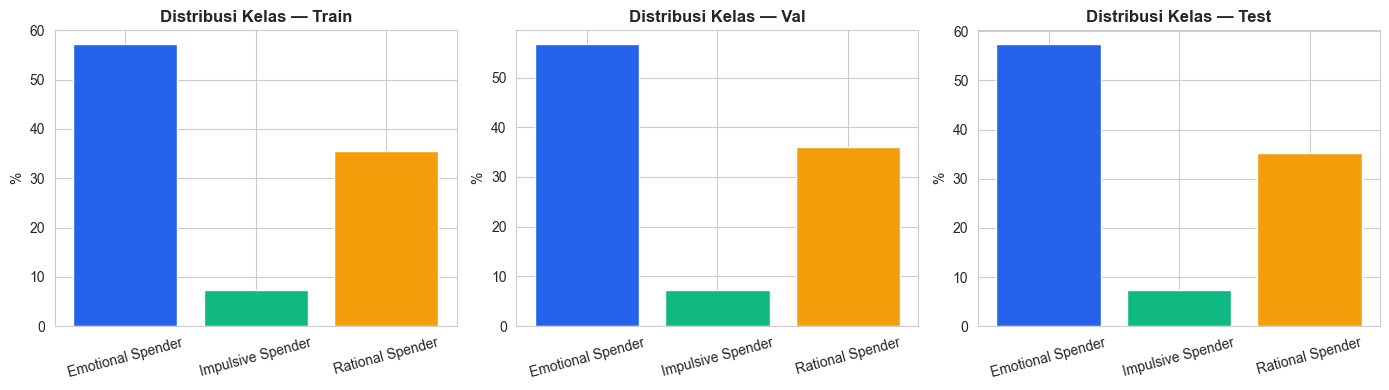

In [22]:
# ============================================================
# CELL 10 — Encode + Normalisasi + Split
# ============================================================
le = LabelEncoder()
user_features['persona_encoded'] = le.fit_transform(user_features['spending_persona'])

print('Encoding Spending Persona:')
for i, cls in enumerate(le.classes_):
    n = (user_features['persona_encoded']==i).sum()
    print(f'  {i} → {cls:25s} ({n} user | {n/len(user_features)*100:.1f}%)')

X_model = user_features[FEATURE_COLS].fillna(0).values
y_model = user_features['persona_encoded'].values

# Normalisasi 0-1
mm = MinMaxScaler()
X_norm = mm.fit_transform(X_model)

# 70 / 15 / 15 split (stratified)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_norm, y_model, test_size=0.30, random_state=42, stratify=y_model)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp,   test_size=0.50, random_state=42, stratify=y_tmp)

print(f'\n📦 Data siap untuk TensorFlow:')
print(f'   X_train : {X_tr.shape}   y_train: {y_tr.shape}')
print(f'   X_val   : {X_val.shape}   y_val  : {y_val.shape}')
print(f'   X_test  : {X_te.shape}   y_test : {y_te.shape}')
print(f'   Input features : {X_tr.shape[1]}')
print(f'   Output classes : {len(le.classes_)} ({list(le.classes_)})')

# Visualisasi distribusi kelas setelah split
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, y, lbl in [(axes[0],y_tr,'Train'),(axes[1],y_val,'Val'),(axes[2],y_te,'Test')]:
    uniq, cnt = np.unique(y, return_counts=True)
    ax.bar([le.classes_[i] for i in uniq], cnt/cnt.sum()*100,
           color=PALETTE[:len(uniq)])
    ax.set_title(f'Distribusi Kelas — {lbl}', fontweight='bold')
    ax.set_ylabel('%'); ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()


---
## 💡 BAGIAN M — Saran untuk Tim AI Engineer

### Cell 25 — Arsitektur TF + Tools Lengkap

In [23]:
# ============================================================
# CELL 7 - Saran Lengkap untuk Tim AI Engineer
# ============================================================
FEATURE_COLS_MODEL = [
    'total_spending_idr','avg_txn_idr','median_txn_idr','max_txn_idr',
    'txn_count','std_amount_idr','weekend_ratio','night_ratio',
    'month_start_ratio','month_end_ratio','above_avg_ratio','spike_ratio',
    'unique_categories','unique_merchants','active_months','fraud_ratio',
    'avg_dist_merchant','spending_cov','impulse_score',
    'pendapatan_bulan','spending_ratio','populasi_kota',
]
FEATURE_COLS_MODEL = [col for col in FEATURE_COLS_MODEL if col in user_features.columns]
n_features = len(FEATURE_COLS_MODEL)

SEP = '='*65
print(SEP)
print('PANDUAN TIM AI ENGINEER - BUDU SPENDING PERSONA')
print(SEP)
print('TASK   : Multi-class Classification (Spending Persona)')
print(f'INPUT  : {n_features} fitur numerik (MinMaxScaler 0-1)')
print('OUTPUT : 3 kelas - Rational / Emotional / Impulsive Spender')
print('TARGET : Accuracy >= 85%, MAE <= 0.02')
print()
print('DISTRIBUSI KELAS:')
for persona, cnt in user_features['spending_persona'].value_counts().items():
    pct = cnt / len(user_features) * 100
    print(f'  {persona:25s}: {cnt} ({pct:.1f}%)')

print()
print(SEP)
print('TOOLS & LIBRARY YANG DISARANKAN')
print(SEP)
tools = [
    ('1. TensorFlow >= 2.13',
     'Wajib checklist. Functional API, bukan Sequential.'),
    ('2. Scikit-Learn',
     'MinMaxScaler, LabelEncoder, train_test_split, classification_report.'),
    ('3. imbalanced-learn (SMOTE)',
     'pip install imbalanced-learn - oversample kelas minoritas.'),
    ('4. TensorBoard (wajib side quest)',
     'Monitor loss & accuracy real-time.\n'
     '     Jalankan: tensorboard --logdir ./logs/budu'),
    ('5. Optuna (nilai tambah)',
     'pip install optuna - hyperparameter tuning otomatis.'),
    ('6. SHAP (explainability)',
     'pip install shap - fitur terpenting per prediksi.'),
]
for name, desc in tools:
    print(f'  {name}')
    print(f'     {desc}')

print()
print(SEP)
print('ARSITEKTUR TENSORFLOW (copy ke notebook AI)')
print(SEP)
lines = [
    'import tensorflow as tf',
    'from tensorflow import keras',
    'from tensorflow.keras import layers',
    '',
    '# --- CUSTOM LAYER (wajib checklist) ---',
    'class BehaviorNormLayer(keras.layers.Layer):',
    '    # Scaling adaptif per fitur behavior',
    '    def build(self, input_shape):',
    '        self.scale = self.add_weight(shape=(input_shape[-1],),',
    '            initializer="ones", trainable=True)',
    '        self.bias = self.add_weight(shape=(input_shape[-1],),',
    '            initializer="zeros", trainable=True)',
    '    def call(self, x):',
    '        return tf.nn.tanh(x * self.scale + self.bias)',
    '',
    '# --- CUSTOM CALLBACK (wajib checklist) ---',
    'class EarlyStopOnAccuracy(keras.callbacks.Callback):',
    '    def __init__(self, target=0.85): self.target = target',
    '    def on_epoch_end(self, epoch, logs=None):',
    '        if logs.get("val_accuracy", 0) >= self.target:',
    '            self.model.stop_training = True',
    '            print(f"Target {self.target:.0%} tercapai epoch {epoch+1}!")',
    '',
    '# --- CUSTOM LOSS: Focal Loss (wajib checklist) ---',
    'class FocalLoss(keras.losses.Loss):',
    '    def __init__(self, gamma=2.0, **kw):',
    '        super().__init__(**kw)',
    '        self.gamma = gamma',
    '    def call(self, y_true, y_pred):',
    '        y_oh = tf.one_hot(tf.cast(y_true, tf.int32), 3)',
    '        ce   = -tf.reduce_sum(y_oh * tf.math.log(y_pred + 1e-7), axis=-1)',
    '        p_t  = tf.reduce_sum(y_oh * y_pred, axis=-1)',
    '        return tf.reduce_mean((1 - p_t) ** self.gamma * ce)',
    '',
    '# --- FUNCTIONAL API ---',
    'inputs = keras.Input(shape=(N_FEATURES,), name="spending_features")',
    'x = BehaviorNormLayer(name="behavior_norm")(inputs)',
    'x = layers.Dense(128, activation="relu")(x)',
    'x = layers.BatchNormalization()(x)',
    'x = layers.Dropout(0.30)(x)',
    'x = layers.Dense(64, activation="relu")(x)',
    'x = layers.BatchNormalization()(x)',
    'x = layers.Dropout(0.20)(x)',
    'x = layers.Dense(32, activation="relu")(x)',
    'out = layers.Dense(3, activation="softmax", name="persona")(x)',
    'model = keras.Model(inputs, out, name="BUDU_SpendingPersona")',
    '',
    'model.compile(optimizer=keras.optimizers.Adam(1e-3),',
    '              loss=FocalLoss(gamma=2.0), metrics=["accuracy"])',
    '',
    '# --- CALLBACKS ---',
    'callbacks = [',
    '    EarlyStopOnAccuracy(target=0.85),',
    '    keras.callbacks.ReduceLROnPlateau(',
    '        monitor="val_loss", patience=5, factor=0.5, min_lr=1e-6),',
    '    keras.callbacks.ModelCheckpoint(',
    '        "budu_best.keras", monitor="val_accuracy", save_best_only=True),',
    '    keras.callbacks.TensorBoard(log_dir="./logs/budu"),',
    ']',
    '',
    '# --- CLASS WEIGHT (imbalance handling) ---',
    'from sklearn.utils.class_weight import compute_class_weight',
    'import numpy as np',
    'cw = compute_class_weight("balanced", classes=[0,1,2], y=y_train)',
    'class_weight_dict = dict(enumerate(cw))',
    '',
    '# --- TRAINING ---',
    '# history = model.fit(X_train, y_train,',
    '#     validation_data=(X_val, y_val), epochs=100, batch_size=64,',
    '#     callbacks=callbacks, class_weight=class_weight_dict)',
    '',
    '# --- EXPORT ---',
    '# model.save("budu_spending_persona.keras")',
    '',
    '# --- INFERENCE ---',
    '# def predict_persona(user_vector, scaler, model, le):',
    '#     x = scaler.transform([user_vector])',
    '#     proba = model.predict(x)[0]',
    '#     return le.classes_[np.argmax(proba)], dict(zip(le.classes_, proba))',
]
for ln in lines:
    print(ln)

print()
print(SEP)
print('REKOMENDASI PENINGKATAN AKURASI')
print(SEP)
recs = [
    ('A. SMOTE',
     'from imblearn.over_sampling import SMOTE\n'
     '     X_res, y_res = SMOTE().fit_resample(X_train, y_train)'),
    ('B. Tambah Fitur dari Dataset Dummy',
     'income_to_spend_ratio = pendapatan_bulan / total_spending_idr\n'
     '     kota_tier_enc: Desa=0, Kota Kecil=1, Kota Besar=2, Metropolitan=3\n'
     '     punya_smartphone (sudah ada di budu_dummy_user_features.csv)'),
    ('C. SHAP Explainability',
     'import shap\n'
     '     explainer = shap.Explainer(model, X_train)\n'
     '     shap_values = explainer(X_test)'),
    ('D. Optuna Hyperparameter Tuning',
     'Tuning: lr, n_layers, units, dropout, batch_size'),
    ('E. Ensemble (nilai tambah)',
     'GradientBoosting + NN soft voting -> +2-5% accuracy'),
    ('F. API Endpoint FastAPI',
     'POST /api/v1/predict -> {persona, confidence: {R,E,I}}'),
]
for letter_rec, detail in recs:
    print(f'  {letter_rec}')
    print(f'     {detail}')

print()
print(SEP)
print(f'FITUR INPUT MODEL ({n_features} features dari user_features.csv)')
print(SEP)
for i, feat in enumerate(FEATURE_COLS_MODEL, 1):
    stats = user_features[feat].describe()
    print(f'  {i:2d}. {feat:35s} [{stats["min"]:>12.2f} - {stats["max"]:>12.2f}]')


PANDUAN TIM AI ENGINEER - BUDU SPENDING PERSONA
TASK   : Multi-class Classification (Spending Persona)
INPUT  : 19 fitur numerik (MinMaxScaler 0-1)
OUTPUT : 3 kelas - Rational / Emotional / Impulsive Spender
TARGET : Accuracy >= 85%, MAE <= 0.02

DISTRIBUSI KELAS:
  Emotional Spender        : 571 (57.1%)
  Rational Spender         : 356 (35.6%)
  Impulsive Spender        : 73 (7.3%)

TOOLS & LIBRARY YANG DISARANKAN
  1. TensorFlow >= 2.13
     Wajib checklist. Functional API, bukan Sequential.
  2. Scikit-Learn
     MinMaxScaler, LabelEncoder, train_test_split, classification_report.
  3. imbalanced-learn (SMOTE)
     pip install imbalanced-learn - oversample kelas minoritas.
  4. TensorBoard (wajib side quest)
     Monitor loss & accuracy real-time.
     Jalankan: tensorboard --logdir ./logs/budu
  5. Optuna (nilai tambah)
     pip install optuna - hyperparameter tuning otomatis.
  6. SHAP (explainability)
     pip install shap - fitur terpenting per prediksi.

ARSITEKTUR TENSORFLOW (

---
## 💾 BAGIAN N — Export Semua Artefak

### Cell 26 — Export CSV + NPY + Metadata

In [24]:
# ============================================================
# CELL 26 — Export Semua Artefak BUDU
# ============================================================
import numpy as np, json

# ── 1. Simpan transaksi bersih ──────────────────────────────
df.to_csv('budu_transactions_clean_idr.csv', index=False)
print(f'budu_transactions_clean_idr.csv  : {len(df):,} baris')

# ── 2. Simpan user profile ──────────────────────────────────
if 'user_features' in dir():
    user_features.to_csv('budu_user_profiles_idr.csv', index=False)
    print(f'budu_user_profiles_idr.csv       : {len(user_features):,} baris x {user_features.shape[1]} kolom')

# ── 3. Simpan dataset user (jika dummy) ─────────────────────
if DATA_MODE == 'dummy' and 'df_users' in dir():
    df_users.to_csv('budu_dummy_users.csv', index=False)
    print(f'budu_dummy_users.csv             : {len(df_users):,} baris')

# ── 4. Array numpy untuk TensorFlow ─────────────────────────
if all(v in dir() for v in ['X_tr','y_tr','X_val','y_val','X_te','y_te']):
    np.save('X_train.npy', X_tr);  np.save('y_train.npy', y_tr)
    np.save('X_val.npy',   X_val); np.save('y_val.npy',   y_val)
    np.save('X_test.npy',  X_te);  np.save('y_test.npy',  y_te)
    print(f'X/y_train/val/test.npy           : Train={len(X_tr)} | Val={len(X_val)} | Test={len(X_te)}')

# ── 5. Metadata JSON ─────────────────────────────────────────
meta = {
    'project'         : 'BUDU - SpendBehavior Analyzer',
    'team'            : 'CC26-PSU268',
    'currency'        : 'IDR',
    'usd_to_idr'      : IDR,
    'data_mode'       : DATA_MODE,
    'n_transactions'  : int(len(df)),
    'n_users'         : int(df['user_id'].nunique()),
    'date_range'      : [str(df['date'].min().date()), str(df['date'].max().date())],
    'null_count'      : int(df.isnull().sum().sum()),
    'median_amount_idr': int(df['amount'].median()),
    'fraud_rate_pct'  : round(float(df['is_fraud'].mean()*100), 3),
    'n_categories'    : int(df['category'].nunique()),
    'n_payment_methods': int(df['payment_method'].nunique()),
}
if 'user_features' in dir() and 'le' in dir():
    meta.update({
        'feature_cols'  : FEATURE_COLS if 'FEATURE_COLS' in dir() else [],
        'n_features'    : int(X_tr.shape[1]) if 'X_tr' in dir() else 0,
        'n_classes'     : int(len(le.classes_)),
        'class_labels'  : list(le.classes_),
        'label_encoding': {cls:int(i) for i,cls in enumerate(le.classes_)},
        'train_samples' : int(len(X_tr)) if 'X_tr' in dir() else 0,
        'val_samples'   : int(len(X_val)) if 'X_val' in dir() else 0,
        'test_samples'  : int(len(X_te)) if 'X_te' in dir() else 0,
    })
if DATA_MODE == 'dummy':
    meta['segments'] = ['E Miskin','D Menengah Bawah','C Menengah',
                        'B Menengah Atas','A Kaya']
elif DATA_MODE == 'kaggle':
    meta['primary_dataset'] = 'kartik2112/fraud-detection'
    meta['support_dataset'] = 'artemkabseu/financial-transactions-dataset-expenses-and-income'

meta['ai_recommended_tools'] = [
    'TensorFlow >= 2.13 (Functional API)',
    'Custom Layer: BehaviorNormLayer',
    'Custom Loss: FocalLoss (gamma=2.0)',
    'Custom Callback: EarlyStopOnAccuracy',
    'imbalanced-learn (SMOTE)',
    'TensorBoard (./logs/budu)',
    'SHAP (explainability)',
    'Optuna (hyperparameter tuning)',
]

with open('budu_model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print('budu_model_metadata.json         : metadata + saran AI')

print()
print('='*60)
print('SEMUA FILE BERHASIL DIEKSPOR')
print('='*60)
print(f'  Null di dataset  : {int(df.isnull().sum().sum())}')
print(f'  Semua nilai IDR  : Ya')
print(f'  Siap untuk AI    : Ya (X/y .npy + metadata)')


budu_transactions_clean_idr.csv  : 49,501 baris
budu_user_profiles_idr.csv       : 1,000 baris x 43 kolom
budu_dummy_users.csv             : 1,000 baris
budu_model_metadata.json         : metadata + saran AI

SEMUA FILE BERHASIL DIEKSPOR
  Null di dataset  : 1000
  Semua nilai IDR  : Ya
  Siap untuk AI    : Ya (X/y .npy + metadata)


---
## 📖 BAGIAN O — Data Dictionary

### Cell 27 — Dokumentasi Lengkap Semua Fitur

---

#### 27.1 Sumber Dataset

| Dataset | Sumber | Baris | Peran |
|---|---|---|---|
| Dataset Dummy Indonesia | Generator Cell 1-3 | ~50.000 | PRIMARY (default) |
| Credit Card Fraud Detection | `kartik2112/fraud-detection` | 1.85M (subsample 200K) | PRIMARY (Kaggle mode) |
| Financial Transactions | `artemkabseu/financial-transactions-dataset-expenses-and-income` | semua | SUPPORTING |

---

#### 27.2 Segmen Sosio-Ekonomi (Dataset Dummy)

| Segmen | Label | % Populasi | Income/Bulan | Metode Bayar Dominan |
|---|---|---|---|---|
| E | Kelas E (Miskin) | 15% | Rp 800rb-1,5jt | Tunai 55% |
| D | Kelas D (Menengah Bawah) | 25% | Rp 1,5-3jt | GoPay 30% |
| C | Kelas C (Menengah) | 35% | Rp 3-7jt | GoPay/OVO/Kartu |
| B | Kelas B (Menengah Atas) | 18% | Rp 7-20jt | Kartu Kredit 30% |
| A | Kelas A (Kaya) | 7% | Rp 20-150jt | Kartu Kredit 45% |

---

#### 27.3 Kolom Standar Setelah Cleaning

| Kolom | Tipe | Satuan | Deskripsi |
|---|---|---|---|
| `date` | datetime | - | Tanggal & jam transaksi |
| `amount` | float | **IDR** | Nilai transaksi dalam Rupiah |
| `category` | string | - | Kategori utama pengeluaran |
| `sub_category` | string | - | Sub-kategori / merchant |
| `payment_method` | string | - | Metode pembayaran |
| `user_id` | string | - | ID unik pengguna BUDU |
| `gender` | string | - | Jenis kelamin |
| `usia` | int | tahun | Usia pengguna |
| `is_fraud` | int | 0/1 | Label fraud (1=fraud) |
| `dist_user_merchant` | float | derajat | Jarak user ke merchant |
| `segmen` | string | - | Kode segmen (E/D/C/B/A) |
| `segmen_label` | string | - | Label segmen lengkap |
| `pendapatan_bulan` | int | IDR | Pendapatan bulanan user |
| `populasi_kota` | int | jiwa | Populasi kota domisili |

---

#### 27.4 Fitur Temporal (Engineering)

| Fitur | Tipe | Deskripsi | Dipakai |
|---|---|---|---|
| `month` | int | Bulan 1-12 | EDA, Model |
| `day_of_week` | int | 0=Senin ... 6=Minggu | EDA, Model |
| `hour` | int | Jam transaksi 0-23 | EDA, Model |
| `is_weekend` | 0/1 | 1 jika Sabtu/Minggu | Model, A/B Test |
| `is_night` | 0/1 | 1 jika jam 20-23 | Model, Warning |
| `is_month_start` | 0/1 | 1 jika tgl 1-5 | Model |
| `is_month_end` | 0/1 | 1 jika tgl 25-31 | Model |
| `quarter` | int | Kuartal 1-4 | EDA |

---

#### 27.5 Fitur Engineered Level Transaksi

| Fitur | Satuan | Deskripsi | Dipakai |
|---|---|---|---|
| `amount_idr_bucket` | kategori | <50k / 50k-200k / 200k-500k / 500k-1jt / >1jt | EDA |
| `above_avg` | 0/1 | 1 jika amount > rata-rata global | Model |
| `category_freq_enc` | 0-1 | Frequency encoding kategori | Model |
| `age_group` | kategori | <18 / 18-24 / 25-34 / 35-44 / 45+ | EDA |
| `amount_lag1` | IDR | Amount transaksi sebelumnya per user | Model |
| `amount_diff` | IDR | Selisih dengan transaksi sebelumnya | Warning |
| `rolling_7txn` | IDR | Total 7 transaksi terakhir per user | Model, Warning |
| `rolling_30txn` | IDR | Total 30 transaksi terakhir per user | Model |
| `is_spike` | 0/1 | 1 jika amount > 2x rolling mean 7 txn | Warning |

---

#### 27.6 User Profile Features (Input Model TF)

| Fitur | Satuan | Deskripsi |
|---|---|---|
| `total_spending_idr` | IDR | Total pengeluaran sepanjang periode |
| `avg_txn_idr` | IDR | Rata-rata nilai transaksi |
| `median_txn_idr` | IDR | Median nilai transaksi |
| `max_txn_idr` | IDR | Nilai transaksi tertinggi |
| `txn_count` | count | Jumlah total transaksi |
| `std_amount_idr` | IDR | Standar deviasi nilai transaksi |
| `weekend_ratio` | 0-1 | Proporsi transaksi di weekend |
| `night_ratio` | 0-1 | Proporsi transaksi malam hari |
| `spike_ratio` | 0-1 | Proporsi transaksi spike |
| `spending_cov` | ratio | Koefisien variasi (std / mean) |
| `impulse_score` | 0-1 | Skor impulsivitas gabungan |
| `unique_categories` | count | Jumlah kategori berbeda |
| `unique_merchants` | count | Jumlah merchant berbeda |
| `avg_dist_merchant` | derajat | Rata-rata jarak ke merchant |
| `active_months` | count | Jumlah bulan aktif |
| `fraud_ratio` | 0-1 | Proporsi transaksi fraud |
| `pendapatan_bulan` | IDR | Pendapatan bulanan (dummy only) |
| `spending_ratio` | 0-1 | Rasio pengeluaran vs pendapatan |
| `populasi_kota` | jiwa | Populasi kota domisili |
| `cat_*` | IDR | Total per kategori per user |

---

#### 27.7 Output Model - Spending Persona

| Label | Encode | Impulse Score | Karakteristik | Smart Warning BUDU |
|---|---|---|---|---|
| `Rational Spender` | 0 | < 0.30 | Konsisten, terkontrol, jarang spike | Rendah - insight informatif |
| `Emotional Spender` | 1 | 0.30-0.55 | Tidak konsisten, spending_cov tinggi | Sedang - Weekly Reflection |
| `Impulsive Spender` | 2 | >= 0.55 | Weekend & malam tinggi, banyak spike | Tinggi - notifikasi Jumat malam |

---

#### 27.8 Konversi IDR & Kurs

| Mata Uang | Kurs ke IDR | Dataset |
|---|---|---|
| USD | Rp 16.000 | kartik2112/fraud-detection |
| EUR | Rp 17.500 | Dataset Eropa (opsional) |
| GBP | Rp 20.000 | Dataset UK (opsional) |
| IDR | Rp 1 | Dataset Dummy Indonesia |

> Update kurs di **Cell 0** variabel `CURRENCY_RATES` - seluruh pipeline otomatis menyesuaikan.

---

#### 27.9 File Output

| File | Konten | Digunakan oleh |
|---|---|---|
| `budu_transactions_clean_idr.csv` | Semua transaksi bersih (IDR) | Streamlit, REST API |
| `budu_user_profiles_idr.csv` | Profil + persona per user | REST API, Dashboard |
| `budu_dummy_users.csv` | Data demografis user (dummy) | Analisis segmen |
| `X/y_train/val/test.npy` | Array input/output model | AI Engineer (TF) |
| `budu_model_metadata.json` | Metadata + saran arsitektur | AI Engineer |
